### 🟠Imports

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from scipy.stats import kruskal

import missingno as msno 
from scipy.stats import f_oneway

import os
import re
import cv2
from IPython.display import Video, display

### 🟢Clinical Demographic Data EDA

Load the dataset & Set plotting style

In [2]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

Clinical_Demographic = pd.read_csv('D:\\TCGA-BRCA\\Uploading\\Clinical_Demographic_Data.csv')

In [3]:
print("### 1. Basic Dataset Overview ###")
print(f"Shape: {Clinical_Demographic.shape}")
print("\nMissing Values Per Column (Top 10):")
print(Clinical_Demographic.isnull().sum().sort_values(ascending=False).head(10))

### 1. Basic Dataset Overview ###
Shape: (122, 84)

Missing Values Per Column (Top 10):
follow_ups_days_to_recurrence                          120
demographic_days_to_death                              119
follow_ups_days_to_progression                         118
diagnoses_tumor_of_origin                              117
follow_ups_progression_or_recurrence                   117
follow_ups_progression_or_recurrence_anatomic_site     117
follow_ups_progression_or_recurrence_type              117
follow_ups_molecular_tests_copy_number                 112
follow_ups_molecular_tests_cell_count                  111
follow_ups_molecular_tests_staining_intensity_scale    103
dtype: int64


Gender & Age & Vital status

C:\Users\USER\AppData\Local\Temp\ipykernel_20024\2968011395.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Clinical_Demographic, x='demographic_gender', ax=axes[0], palette='viridis')
C:\Users\USER\AppData\Local\Temp\ipykernel_20024\2968011395.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Clinical_Demographic, x='demographic_vital_status', ax=axes[2], palette='magma')


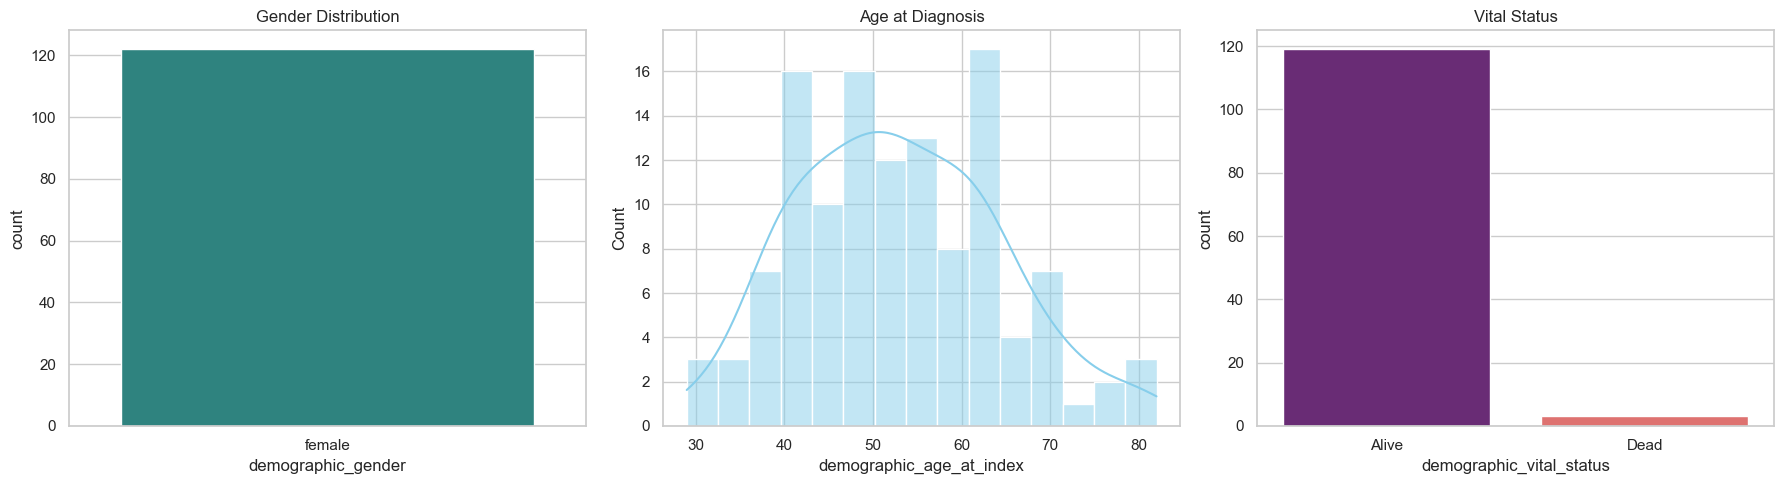

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=Clinical_Demographic, x='demographic_gender', ax=axes[0], palette='viridis')
axes[0].set_title('Gender Distribution')

sns.histplot(Clinical_Demographic['demographic_age_at_index'], bins=15, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Age at Diagnosis')

sns.countplot(data=Clinical_Demographic, x='demographic_vital_status', ax=axes[2], palette='magma')
axes[2].set_title('Vital Status')
plt.tight_layout()
plt.show()

Distribution of Pathologic Stages

C:\Users\USER\AppData\Local\Temp\ipykernel_20024\1969775097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Clinical_Demographic, y='diagnoses_ajcc_pathologic_stage', order=order, palette='Set2')


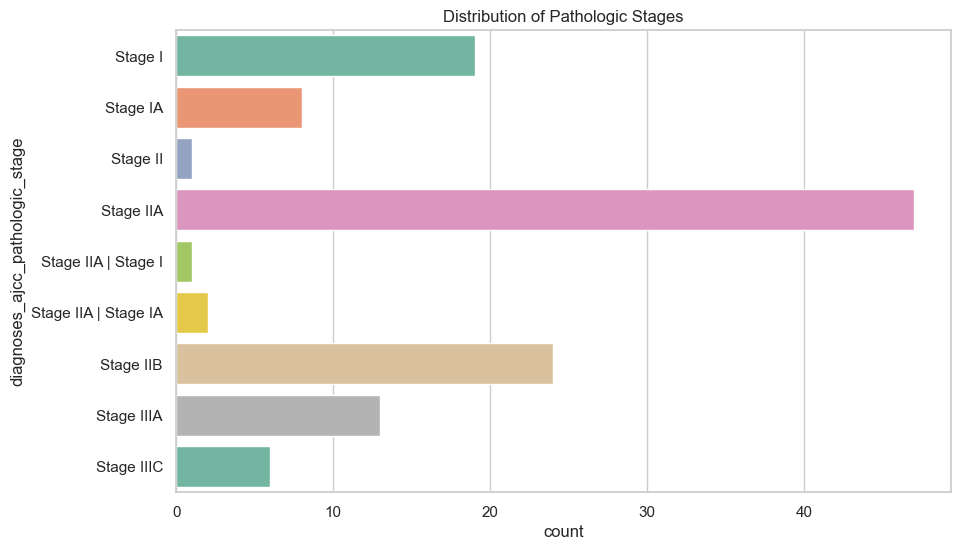

In [5]:
plt.figure(figsize=(10, 6))
order = sorted(Clinical_Demographic['diagnoses_ajcc_pathologic_stage'].dropna().unique())
sns.countplot(data=Clinical_Demographic, y='diagnoses_ajcc_pathologic_stage', order=order, palette='Set2')
plt.title('Distribution of Pathologic Stages')
plt.show()

Molecular Markers Analysis (Handling Piped Values)

C:\Users\USER\AppData\Local\Temp\ipykernel_20024\1623374657.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Clinical_Demographic, x='primary_gene', palette='rocket')


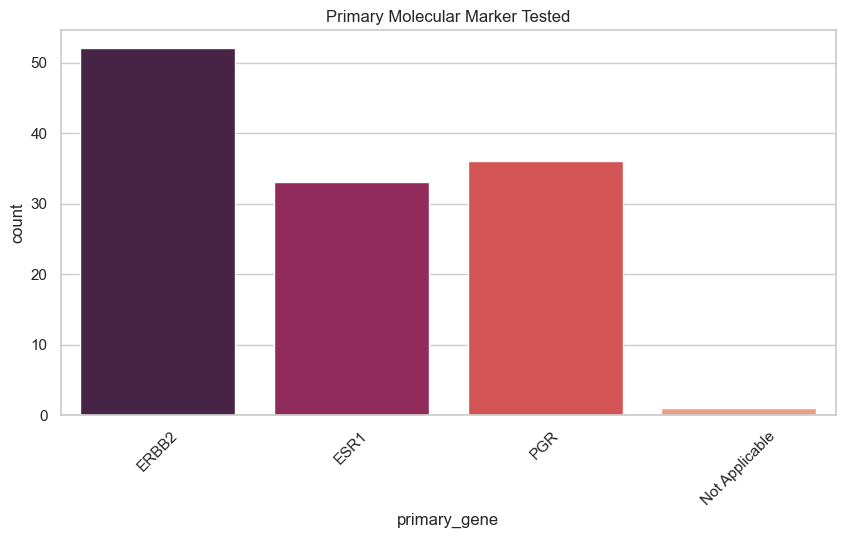

In [6]:
# Many values are "ERBB2 | PGR | ESR1". Let's see the primary gene listed.
Clinical_Demographic['primary_gene'] = Clinical_Demographic['follow_ups_molecular_tests_gene_symbol'].str.split('|').str[0].str.strip()

plt.figure(figsize=(10, 5))
sns.countplot(data=Clinical_Demographic, x='primary_gene', palette='rocket')
plt.title('Primary Molecular Marker Tested')
plt.xticks(rotation=45)
plt.show()

Treatment Analysi

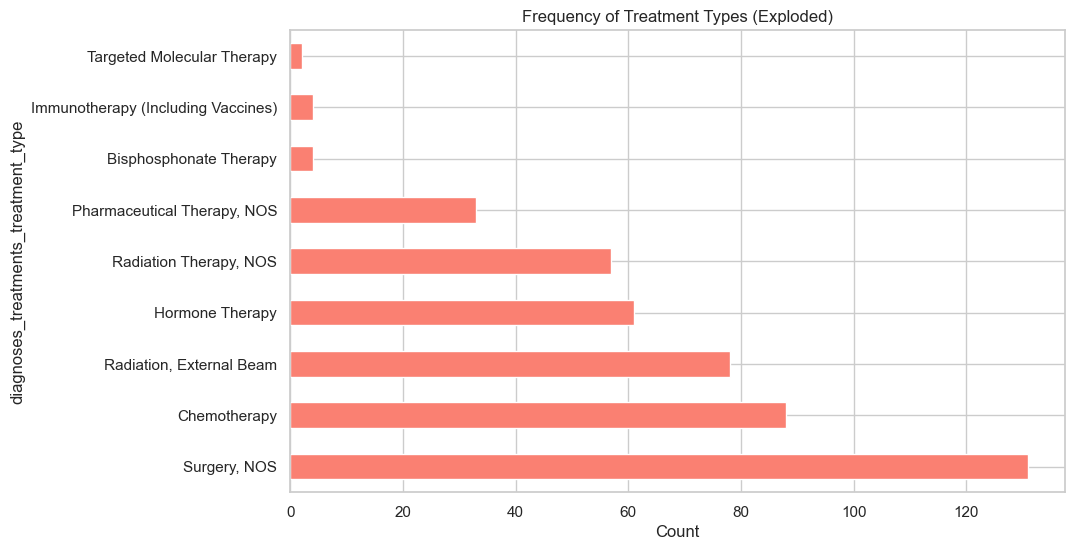

In [7]:
# Splitting the piped treatment types to see what's most common
all_treatments = Clinical_Demographic['diagnoses_treatments_treatment_type'].str.split('|').explode().str.strip()

plt.figure(figsize=(10, 6))
all_treatments.value_counts().plot(kind='barh', color='salmon')
plt.title('Frequency of Treatment Types (Exploded)')
plt.xlabel('Count')
plt.show()

Correlation Heatmap 

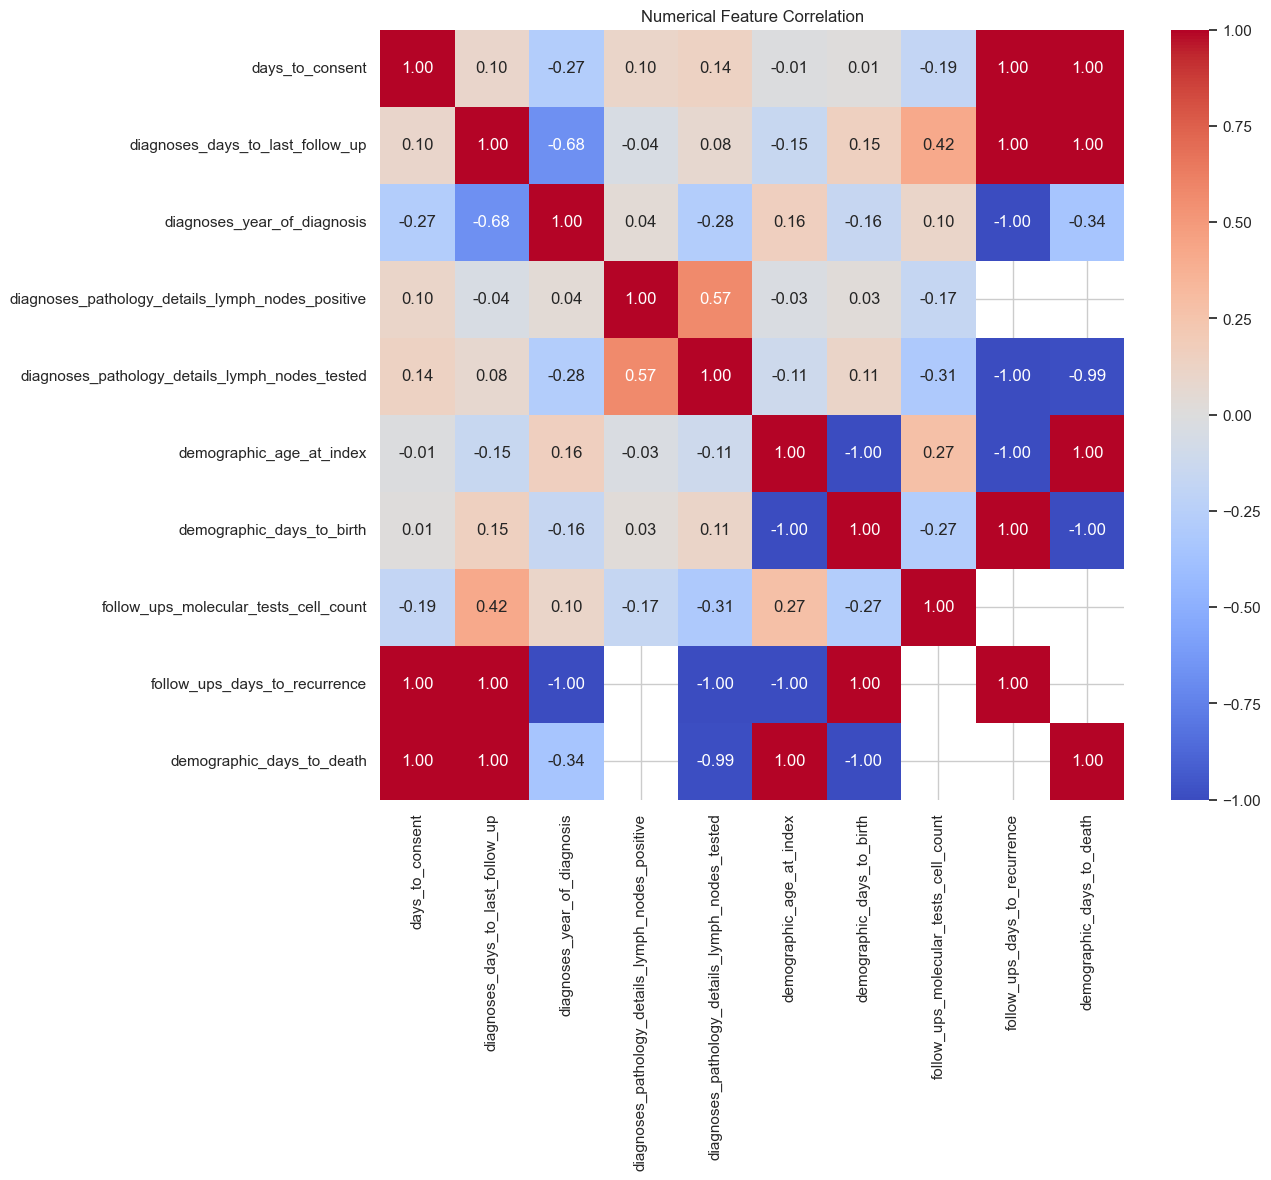

In [8]:
plt.figure(figsize=(12, 10))
numeric_cols = Clinical_Demographic.select_dtypes(include=[np.number]).columns
# Filter out columns with all NaNs
numeric_cols = [c for c in numeric_cols if Clinical_Demographic[c].nunique() > 1]
sns.heatmap(Clinical_Demographic[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Feature Correlation')
plt.show()

Specialized Insights

In [9]:
print("\n### 3. Clinical Insights ###")
# Average age by Menopause Status
if 'follow_ups_other_clinical_attributes_menopause_status' in Clinical_Demographic.columns:
    menopause_age = Clinical_Demographic.groupby('follow_ups_other_clinical_attributes_menopause_status')['demographic_age_at_index'].mean()
    print("\nAverage Age by Menopause Status:")
    print(menopause_age)



### 3. Clinical Insights ###

Average Age by Menopause Status:
follow_ups_other_clinical_attributes_menopause_status
Perimenopausal    49.666667
Postmenopausal    61.262295
Premenopausal     42.791667
Unknown           49.666667
Name: demographic_age_at_index, dtype: float64


Helper functions

In [10]:
def get_first_val(x):
    if pd.isna(x): return np.nan
    return str(x).split('|')[0].strip()

def extract_marker_status(row, marker_name):
    try:
        genes = str(row['follow_ups_molecular_tests_gene_symbol']).split('|')
        results = str(row['follow_ups_molecular_tests_test_result']).split('|')
        gene_map = dict(zip([g.strip() for g in genes], [r.strip() for r in results]))
        return gene_map.get(marker_name, "Unknown")
    except:
        return "Unknown"

Data Cleaning and Feature Engineering

In [11]:
# 1. Basic Cleaning
Clinical_Demographic['clean_stage'] = Clinical_Demographic['diagnoses_ajcc_pathologic_stage'].str.extract(r'(Stage [IV]+)')
Clinical_Demographic['age'] = Clinical_Demographic['demographic_age_at_index']

# 2. Molecular Subtyping
Clinical_Demographic['ER_Status'] = Clinical_Demographic.apply(lambda x: extract_marker_status(x, 'ESR1'), axis=1)
Clinical_Demographic['PR_Status'] = Clinical_Demographic.apply(lambda x: extract_marker_status(x, 'PGR'), axis=1)
Clinical_Demographic['HER2_Status'] = Clinical_Demographic.apply(lambda x: extract_marker_status(x, 'ERBB2'), axis=1)

# 3. Survival Prep
# TCGA: If death days is NaN, use last follow up
Clinical_Demographic['duration'] = Clinical_Demographic['demographic_days_to_death'].fillna(Clinical_Demographic['diagnoses_days_to_last_follow_up'])
Clinical_Demographic['event'] = Clinical_Demographic['demographic_vital_status'].map({'Dead': 1, 'Alive': 0})

Age Distribution by Stage

C:\Users\USER\AppData\Local\Temp\ipykernel_20024\3942438498.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Clinical_Demographic, x='clean_stage', y='age', palette='vlag')


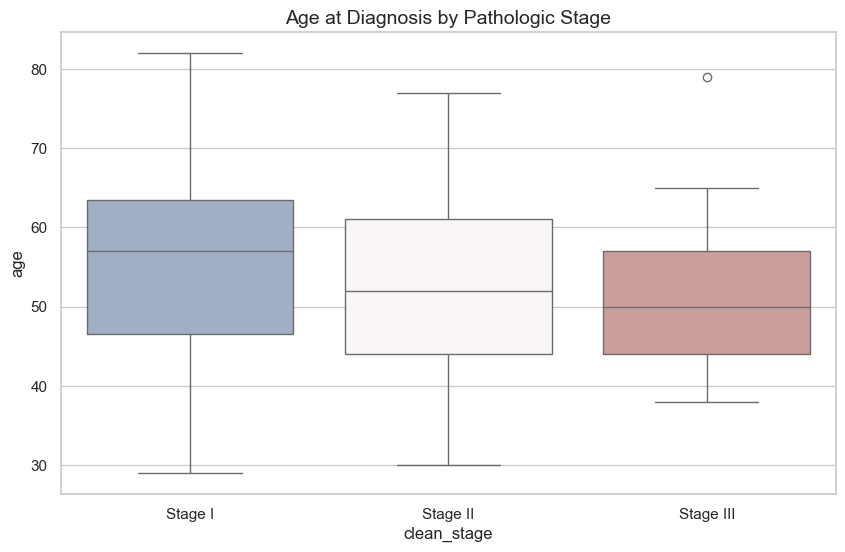

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=Clinical_Demographic, x='clean_stage', y='age', palette='vlag')
plt.title('Age at Diagnosis by Pathologic Stage', fontsize=14)
plt.show()

Molecular Marker Distribution

<Figure size 1000x600 with 0 Axes>

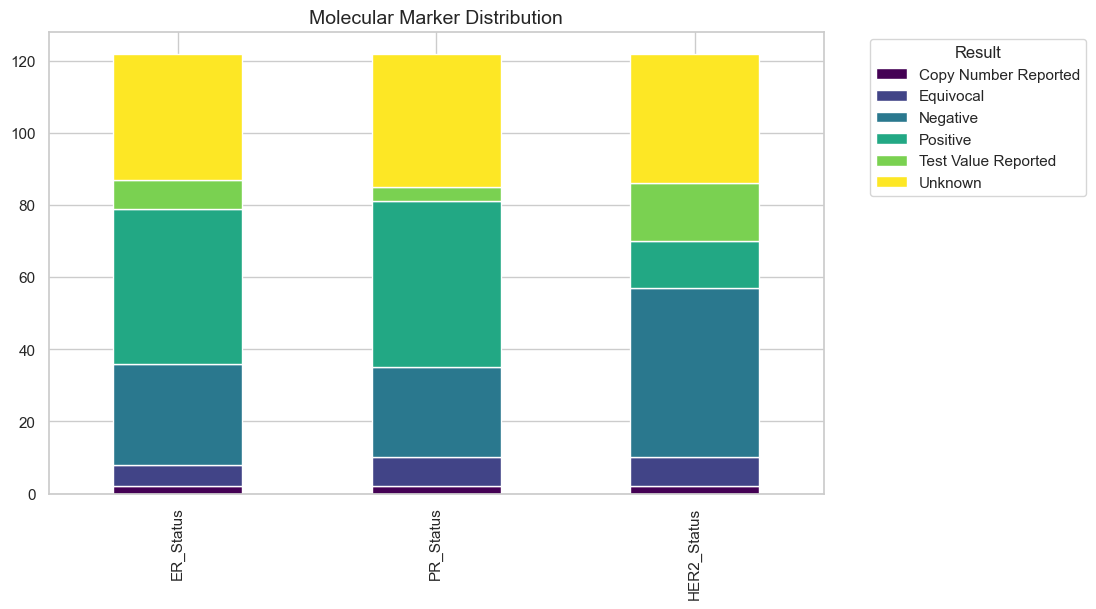

In [13]:
plt.figure(figsize=(10, 6))
marker_counts = Clinical_Demographic[['ER_Status', 'PR_Status', 'HER2_Status']].apply(pd.Series.value_counts).T
marker_counts.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title('Molecular Marker Distribution', fontsize=14)
plt.legend(title="Result", bbox_to_anchor=(1.05, 1), loc='upper left')

Treatment Modalities

C:\Users\USER\AppData\Local\Temp\ipykernel_20024\52300960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=treatments, palette='rocket')


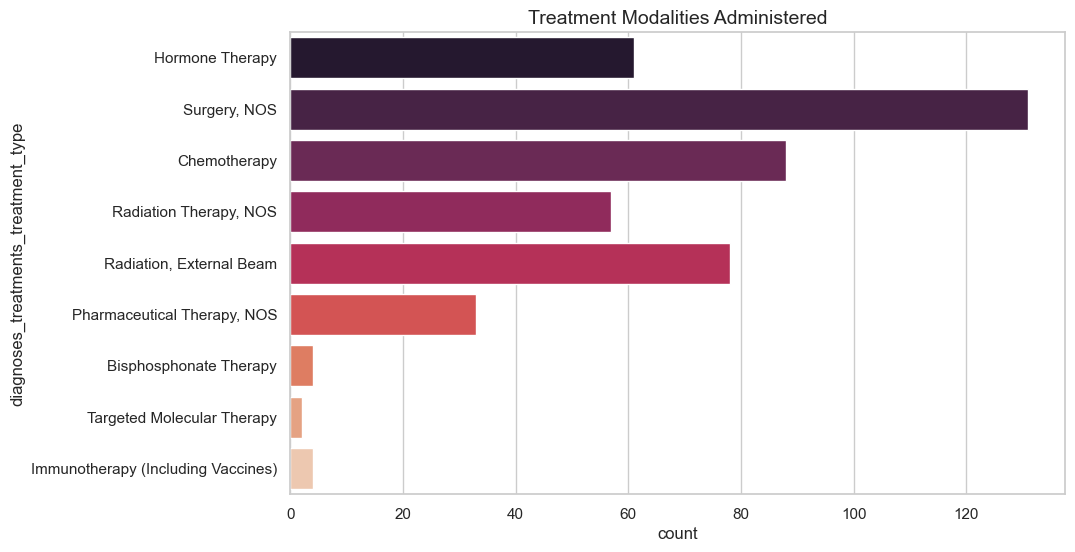

In [14]:
plt.figure(figsize=(10, 6))
treatments = Clinical_Demographic['diagnoses_treatments_treatment_type'].str.split('|').explode().str.strip()
sns.countplot(y=treatments, palette='rocket')
plt.title('Treatment Modalities Administered', fontsize=14)
plt.show()

Survival Analysis (Kaplan-Meier)

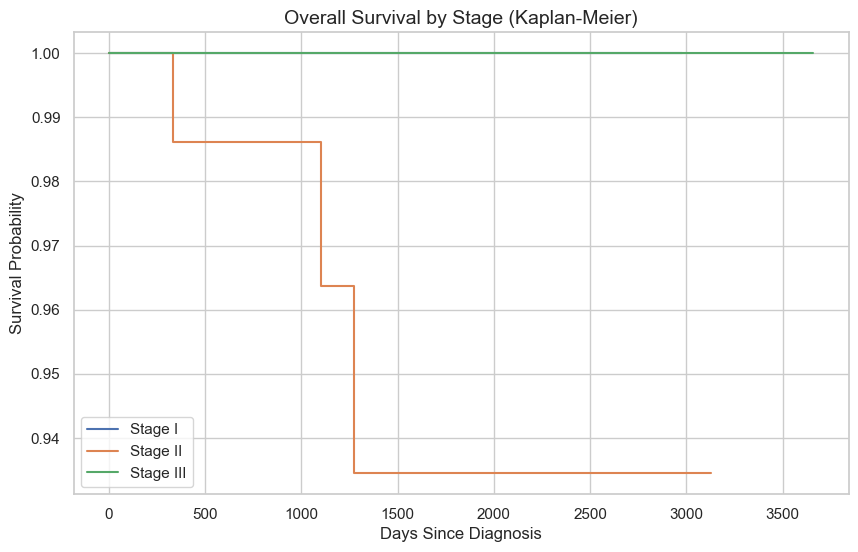

In [15]:
plt.figure(figsize=(10, 6))
kmf = KaplanMeierFitter()

# Iterate through stages to plot multiple curves
for stage in Clinical_Demographic['clean_stage'].dropna().unique():
    mask = (Clinical_Demographic['clean_stage'] == stage)
    # Ensure there is data to plot for the stage
    if mask.any():
        kmf.fit(Clinical_Demographic[mask]['duration'], 
                Clinical_Demographic[mask]['event'], 
                label=stage)
        kmf.plot_survival_function(ci_show=False)

plt.title('Overall Survival by Stage (Kaplan-Meier)', fontsize=14)
plt.xlabel('Days Since Diagnosis')
plt.ylabel('Survival Probability')
plt.show()

Statistical Summary

In [16]:
print("--- CLINICAL COHORT SUMMARY ---")
summary = Clinical_Demographic[['age', 'clean_stage', 'demographic_vital_status']].describe(include='all')
display(summary)

--- CLINICAL COHORT SUMMARY ---


,age,clean_stage,demographic_vital_status
count,122.000000,121,122
unique,NaN,3,2
top,NaN,Stage II,Alive
freq,NaN,75,119
mean,52.901639,NaN,NaN
std,11.341003,NaN,NaN
min,29.000000,NaN,NaN
25%,44.250000,NaN,NaN
50%,52.000000,NaN,NaN
75%,61.000000,NaN,NaN


### 🔵Clinical Treatment Data EDA

Data Loading and Preprocessing

In [17]:
# 1. Load the Data
# Note: Ensure the file path is accessible from your notebook environment
Clinical_Treatment = pd.read_csv('D:\\TCGA-BRCA\\Uploading\\Clinical_Treatment_Data.csv')

# --- DATA PREPARATION ---
# Clean vital status robustly
Clinical_Treatment['vital_status_clean'] = Clinical_Treatment['vital_status'].astype(str).str.strip().str.lower()
Clinical_Treatment['event_observed'] = Clinical_Treatment['vital_status_clean'].apply(lambda x: 1 if x in ['dead', 'deceased'] else 0)

# Clean Drug Columns (creating grouped binary columns)
drug_mappings = {
    'Fluorouracil': [c for c in Clinical_Treatment.columns if 'fluoro' in c.lower() or '5-fu' in c.lower()],
    'Cyclophosphamide': [c for c in Clinical_Treatment.columns if 'cyclo' in c.lower() or 'cytoxan' in c.lower()],
    'Doxorubicin': [c for c in Clinical_Treatment.columns if 'doxorubicin' in c.lower() or 'adriamycin' in c.lower()],
    'Paclitaxel': [c for c in Clinical_Treatment.columns if 'paclitaxel' in c.lower() or 'taxol' in c.lower()],
    'Trastuzumab': [c for c in Clinical_Treatment.columns if 'trastuzumab' in c.lower() or 'herceptin' in c.lower()],
    'Hormone_Therapy': [c for c in Clinical_Treatment.columns if 'tamoxifen' in c.lower() or 'letrozole' in c.lower() or 'anastrozole' in c.lower()]
}

for new_col, old_cols in drug_mappings.items():
    Clinical_Treatment[new_col] = Clinical_Treatment[old_cols].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)

# Define Clinical Subtypes
def determine_subtype(row):
    er, pr, her2 = str(row['er_status_by_ihc']).lower(), str(row['pr_status_by_ihc']).lower(), str(row['her2_status_by_ihc']).lower()
    if 'positive' in er or 'positive' in pr:
        return 'HR+/HER2-' if her2 != 'positive' else 'HR+/HER2+' 
    elif her2 == 'positive':
        return 'HER2+ (HR-)'
    elif er == 'negative' and pr == 'negative' and her2 == 'negative':
        return 'TNBC'
    return 'Unknown'

Clinical_Treatment['Subtype'] = Clinical_Treatment.apply(determine_subtype, axis=1)
print("Data Preprocessing Complete.")

Data Preprocessing Complete.


Age at Diagnosis by Subtype

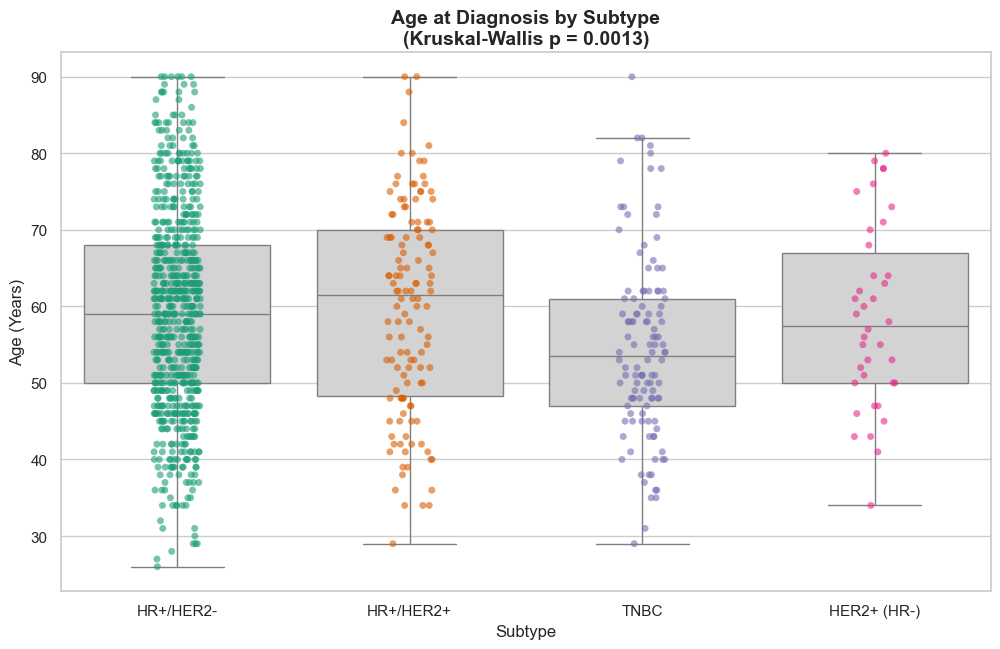

In [18]:
plt.figure(figsize=(12, 7))

# Filter data for visualization
valid_age_df = Clinical_Treatment.dropna(subset=['age_at_diagnosis', 'Subtype'])
valid_age_df = valid_age_df[valid_age_df['Subtype'] != 'Unknown']

# Create plot
sns.boxplot(data=valid_age_df, x='Subtype', y='age_at_diagnosis', color="lightgray", showfliers=False)
sns.stripplot(data=valid_age_df, x='Subtype', y='age_at_diagnosis', alpha=0.6, jitter=True, palette="Dark2", hue='Subtype', legend=False)

# Statistical Test
groups = [group["age_at_diagnosis"].values for name, group in valid_age_df.groupby("Subtype")]
if len(groups) > 1:
    stat, p_val = kruskal(*groups)
    plt.title(f'Age at Diagnosis by Subtype\n(Kruskal-Wallis p = {p_val:.4f})', fontweight='bold', fontsize=14)
else:
    plt.title('Age at Diagnosis by Subtype', fontweight='bold', fontsize=14)

plt.ylabel('Age (Years)')
plt.show()

Treatment Co-occurrence Heatmap

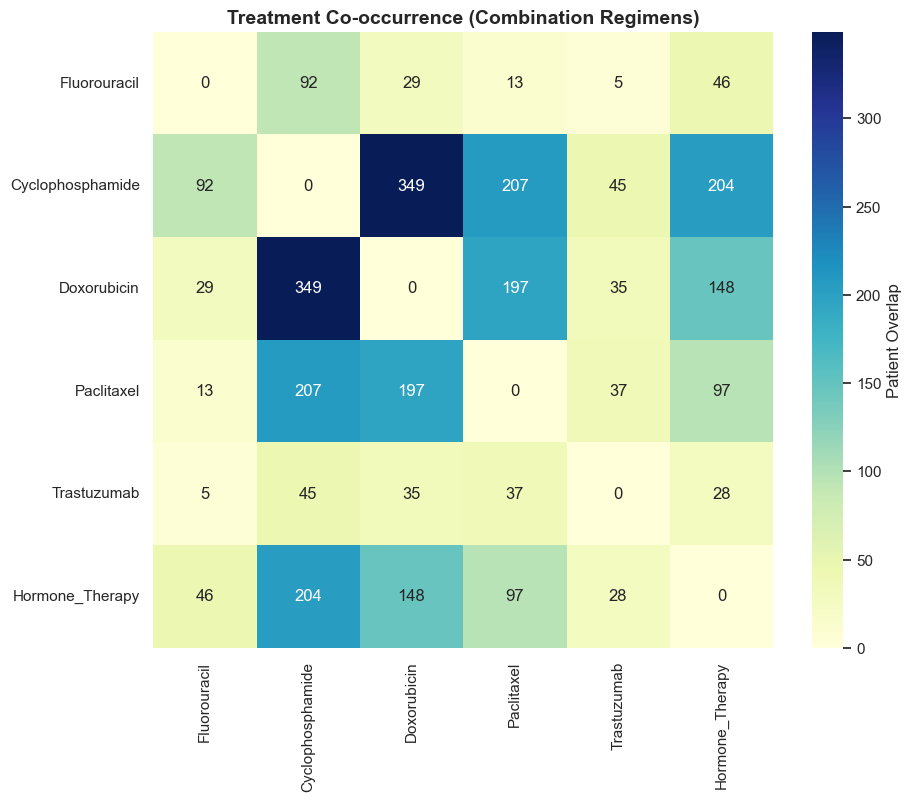

In [19]:
plt.figure(figsize=(10, 8))

drug_cols = list(drug_mappings.keys())
co_occurrence = Clinical_Treatment[drug_cols].T.dot(Clinical_Treatment[drug_cols])
np.fill_diagonal(co_occurrence.values, 0) # Highlight relationships by removing self-overlap

sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Patient Overlap'})
plt.title('Treatment Co-occurrence (Combination Regimens)', fontweight='bold', fontsize=14)
plt.show()

Kaplan-Meier Survival Analysis

Total events (deaths) captured: 0


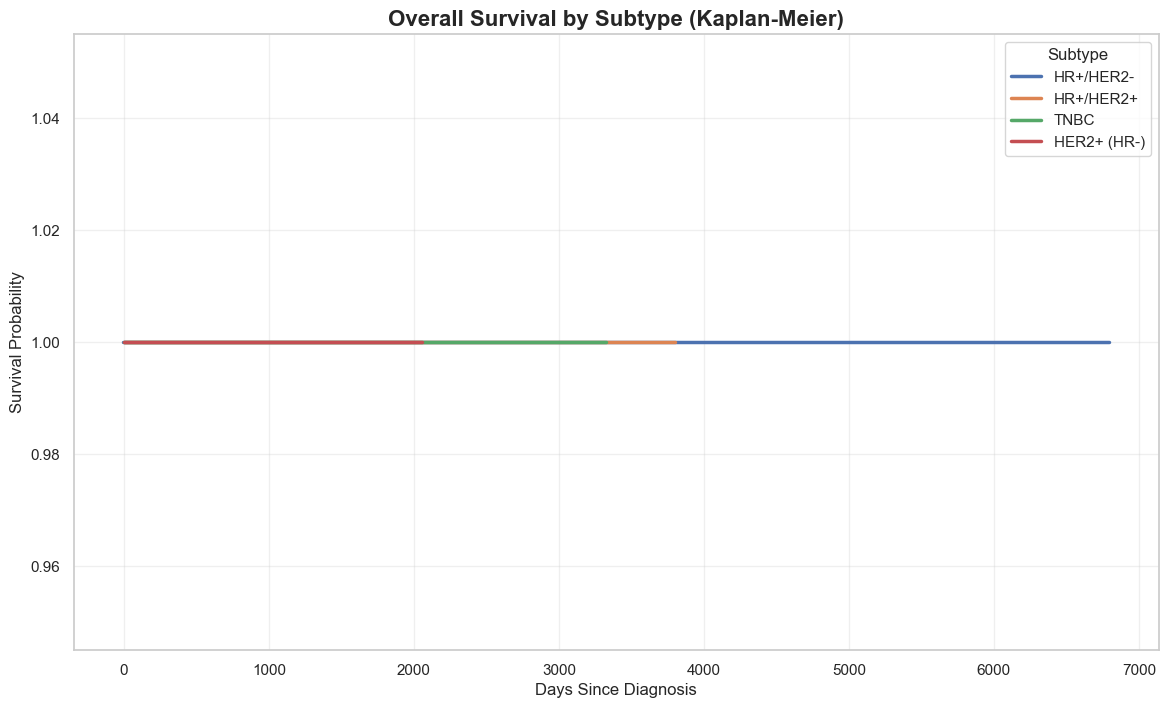

In [20]:
plt.figure(figsize=(14, 8))
kmf = KaplanMeierFitter()

# Clean records missing survival time
surv_df = Clinical_Treatment.dropna(subset=['last_contact_days_to']).copy()

print(f"Total events (deaths) captured: {surv_df['event_observed'].sum()}") 

for subtype in surv_df['Subtype'].unique():
    if subtype == 'Unknown': 
        continue
        
    mask = surv_df['Subtype'] == subtype
    # Filter for subtypes with enough data points to be statistically relevant
    if mask.sum() > 5: 
        kmf.fit(surv_df['last_contact_days_to'][mask], 
                surv_df['event_observed'][mask], 
                label=subtype)
        
        # ci_show=True adds shaded confidence intervals
        kmf.plot_survival_function(ci_show=True, linewidth=2.5)

plt.title('Overall Survival by Subtype (Kaplan-Meier)', fontweight='bold', fontsize=16)
plt.xlabel('Days Since Diagnosis')
plt.ylabel('Survival Probability')
plt.legend(title="Subtype")
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
print("--- COHORT BREAKDOWN ---")
print(Clinical_Treatment['Subtype'].value_counts())
print("\n--- TREATMENT FREQUENCIES ---")
print(Clinical_Treatment[list(drug_mappings.keys())].sum())

--- COHORT BREAKDOWN ---
Subtype
HR+/HER2-      699
HR+/HER2+      126
Unknown        118
TNBC           116
HER2+ (HR-)     38
Name: count, dtype: int64

--- TREATMENT FREQUENCIES ---
Fluorouracil         92
Cyclophosphamide    507
Doxorubicin         357
Paclitaxel          226
Trastuzumab          73
Hormone_Therapy     340
dtype: int64


DATA QUALITY AUDIT

<Figure size 800x400 with 0 Axes>

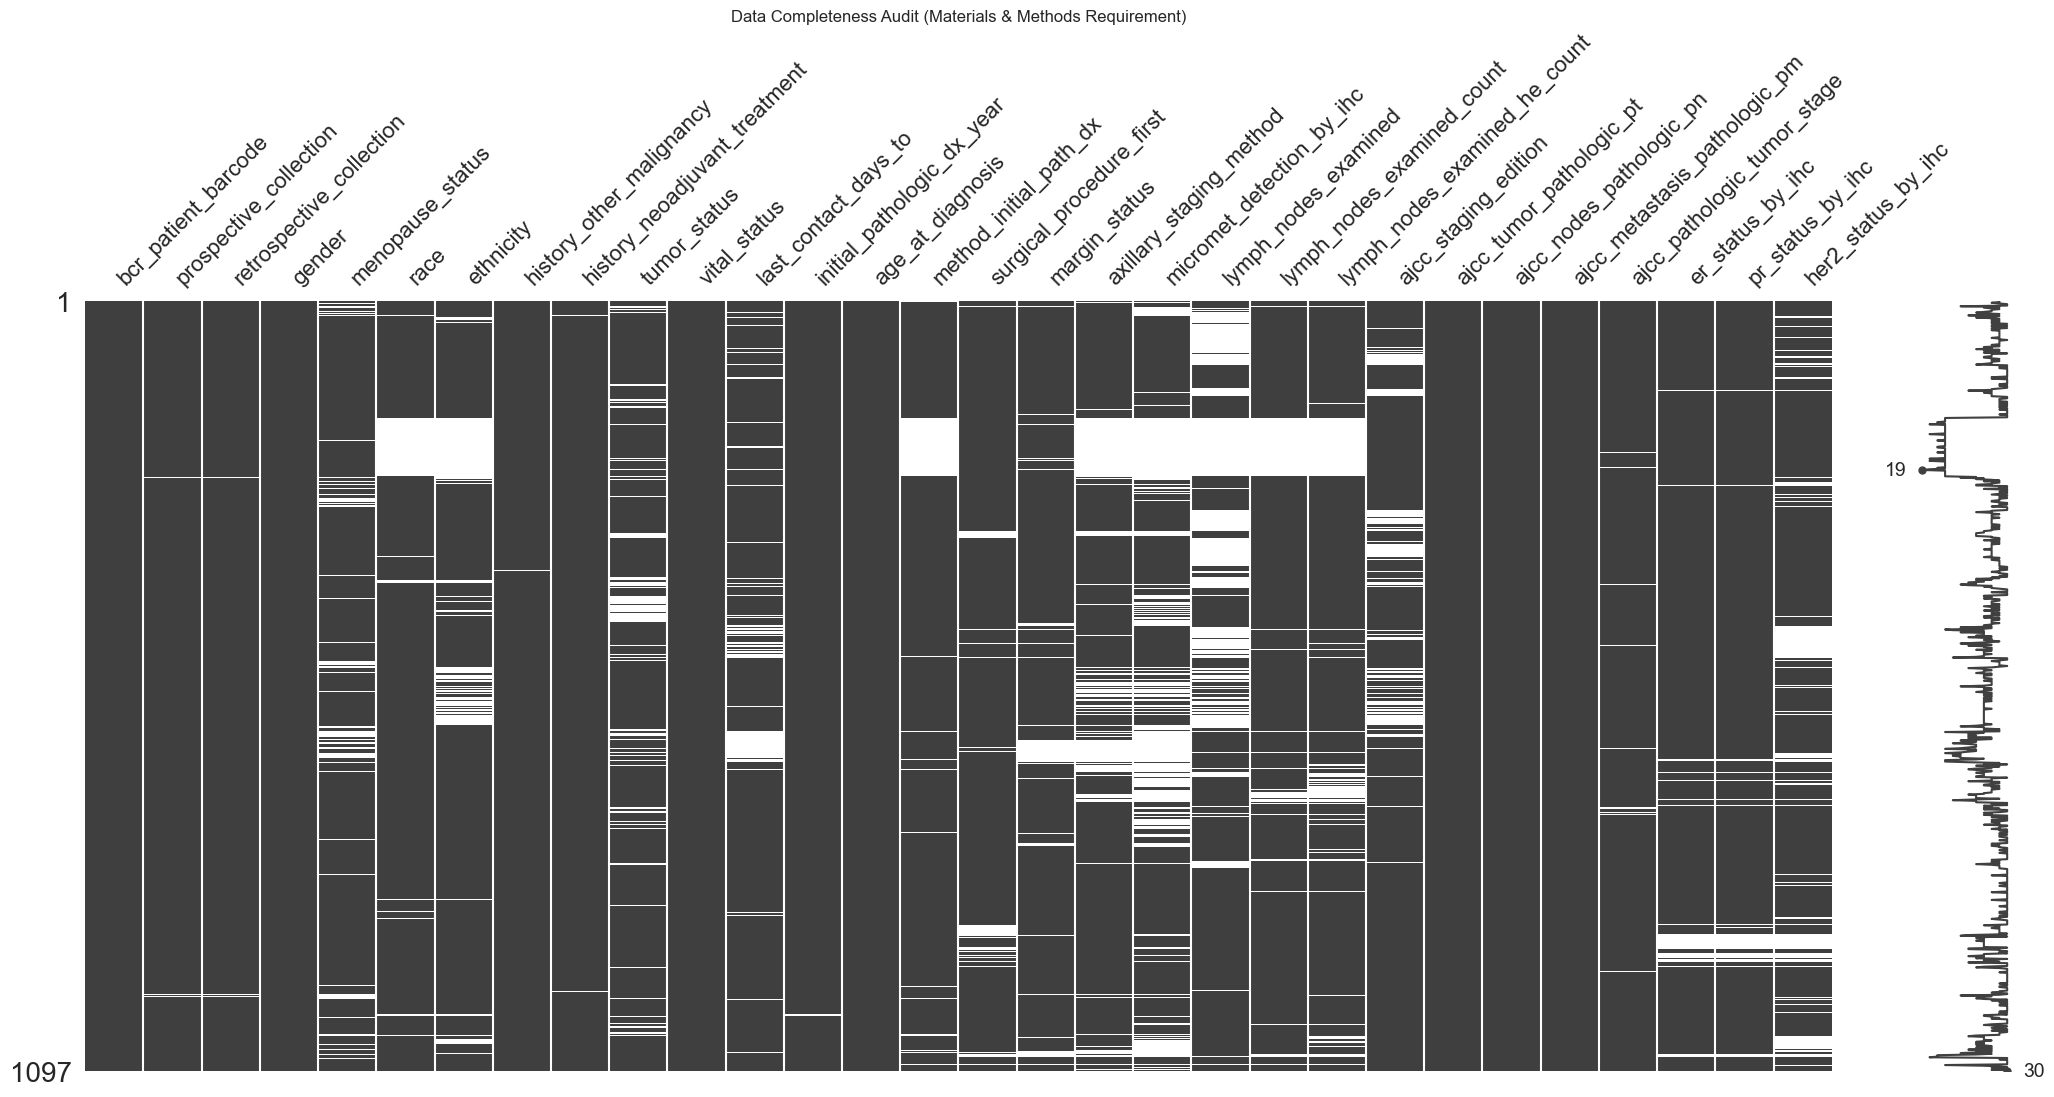

In [22]:
plt.figure(figsize=(8, 4))
msno.matrix(Clinical_Treatment.iloc[:, :30]) # Audit first 30 columns for missingness
plt.title("Data Completeness Audit (Materials & Methods Requirement)")
plt.show()


ADVANCED PATHOLOGICAL ANALYSIS

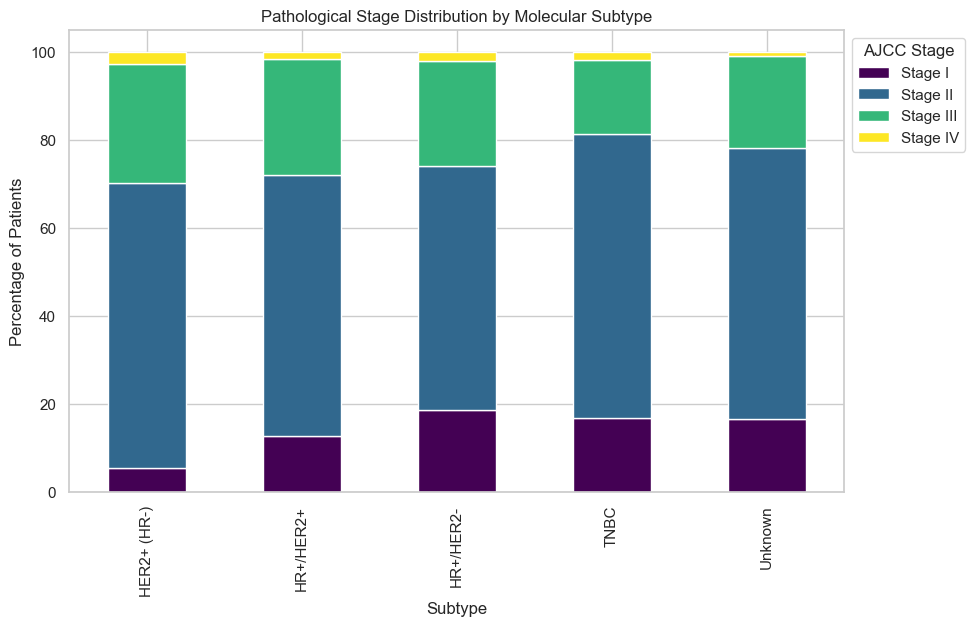

In [23]:
# Simplify Stage for better visualization
Clinical_Treatment['stage_simple'] = Clinical_Treatment['ajcc_pathologic_tumor_stage'].str.extract(r'(Stage [I|V]+)')

# Cross-tabulation of Subtype vs Stage
ct = pd.crosstab(Clinical_Treatment['Subtype'], Clinical_Treatment['stage_simple'], normalize='index') * 100

ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title("Pathological Stage Distribution by Molecular Subtype")
plt.ylabel("Percentage of Patients")
plt.legend(title="AJCC Stage", bbox_to_anchor=(1,1))
plt.show()

THE DOCTORAL STEP: COX PROPORTIONAL HAZARDS

In [24]:
# Preparing data for Cox: Must be numeric and no NaNs
cols_to_use = ['last_contact_days_to', 'event_observed', 'age_at_diagnosis', 'Subtype', 'stage_simple']
cox_data = Clinical_Treatment[cols_to_use].dropna()

# Convert categorical to one-hot encoding
cox_data_encoded = pd.get_dummies(cox_data, columns=['Subtype', 'stage_simple'], drop_first=True)

# Convert boolean columns to integers 
for col in cox_data_encoded.columns:
    if cox_data_encoded[col].dtype == 'bool':
        cox_data_encoded[col] = cox_data_encoded[col].astype(int)

print(f"Data prepared for Cox Model. Total samples: {len(cox_data_encoded)}")
display(cox_data_encoded.head())
print("--- COX PROPORTIONAL HAZARDS MODEL ---")

cph = CoxPHFitter()

try:
    cph.fit(cox_data_encoded, duration_col='last_contact_days_to', event_col='event_observed')
    cph.print_summary()  # Displays the statistical table
except Exception as e:
    print(f"Model failed: {e}")
    print("Tip: This often happens if there are too few 'event_observed' (deaths) or high multicollinearity.")

# Plotting the Forest Plot (Essential for papers!)
plt.figure(figsize=(10, 6))

try:
    cph.plot()
    plt.title("Hazard Ratios for Clinical Features (Cox Model)", fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.5) # Reference line at HR = 1 (log scale 0)
    plt.xlabel("Log Hazard Ratio")
    plt.show()
except:
    print("Plot could not be generated. Ensure the model has been fitted successfully first.")

Data prepared for Cox Model. Total samples: 978


,last_contact_days_to,event_observed,age_at_diagnosis,Subtype_HR+/HER2+,Subtype_HR+/HER2-,Subtype_TNBC,Subtype_Unknown,stage_simple_Stage II,stage_simple_Stage III,stage_simple_Stage IV
1,3801.0,0,50,1,0,0,0,1,0,0
2,1228.0,0,62,0,1,0,0,1,0,0
3,1217.0,0,52,1,0,0,0,0,0,0
4,158.0,0,50,0,1,0,0,0,1,0
5,1477.0,0,42,0,1,0,0,1,0,0


--- COX PROPORTIONAL HAZARDS MODEL ---
Model failed: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.
Tip: This often happens if there are too few 'event_observed' (deaths) or high multicollinearity.
Plot could not be generated. Ensure the model has been fitted successfully first.


<Figure size 1000x600 with 0 Axes>

Calculate Lymph Node Ratio (LNR) 

C:\Users\USER\AppData\Local\Temp\ipykernel_20024\1161442049.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=Clinical_Treatment, x='Subtype', y='LNR', inner="quart", palette="muted")


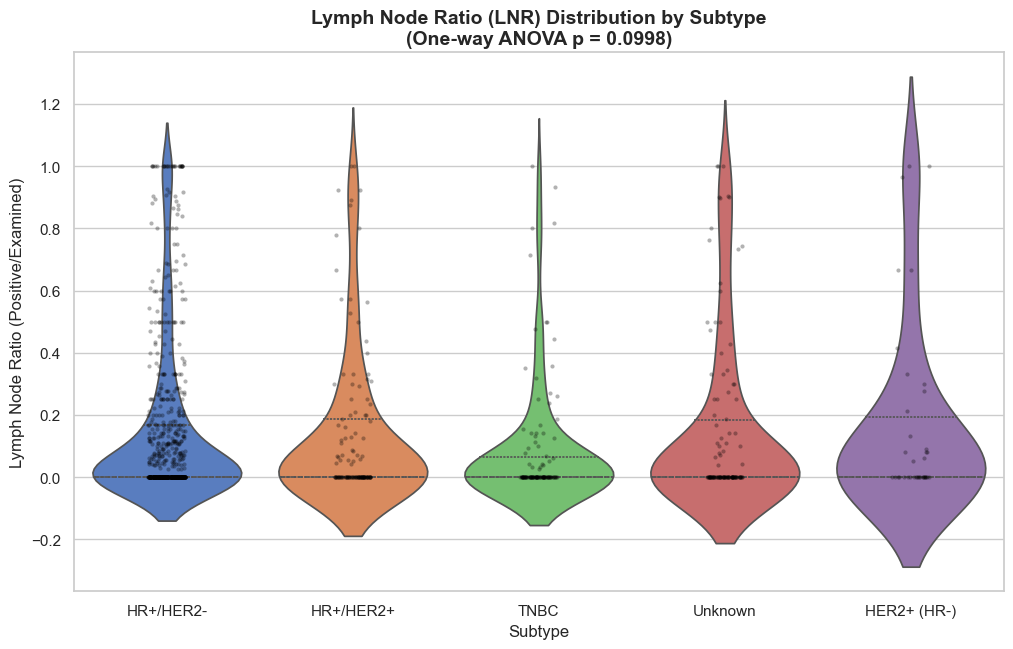

In [25]:
# LNR = (Positive Nodes / Total Nodes Examined)
# We handle division by zero or NaN
Clinical_Treatment['LNR'] = Clinical_Treatment['lymph_nodes_examined_he_count'] / Clinical_Treatment['lymph_nodes_examined_count']
Clinical_Treatment['LNR'] = Clinical_Treatment['LNR'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Advanced Visualization: LNR by Subtype
plt.figure(figsize=(12, 7))
sns.violinplot(data=Clinical_Treatment, x='Subtype', y='LNR', inner="quart", palette="muted")
sns.stripplot(data=Clinical_Treatment, x='Subtype', y='LNR', color="black", size=3, alpha=0.3)

# Statistical Validation (ANOVA)
subtypes = Clinical_Treatment['Subtype'].unique()
group_data = [Clinical_Treatment[Clinical_Treatment['Subtype'] == s]['LNR'].dropna() for s in subtypes if s != 'Unknown']
f_stat, p_val = f_oneway(*group_data)

plt.title(f"Lymph Node Ratio (LNR) Distribution by Subtype\n(One-way ANOVA p = {p_val:.4f})", 
          fontsize=14, fontweight='bold')
plt.ylabel("Lymph Node Ratio (Positive/Examined)")
plt.show()



Summary Table for your Thesis

In [26]:
clinical_summary = Clinical_Treatment.groupby('Subtype').agg({
    'age_at_diagnosis': 'median',
    'lymph_nodes_examined_count': 'mean',
    'LNR': 'mean',
    'bcr_patient_barcode': 'count'
}).rename(columns={'bcr_patient_barcode': 'N'})

print("--- TABLE 1: CLINICAL CHARACTERISTICS BY MOLECULAR SUBTYPE ---")
print(clinical_summary.round(3))

--- TABLE 1: CLINICAL CHARACTERISTICS BY MOLECULAR SUBTYPE ---
             age_at_diagnosis  lymph_nodes_examined_count    LNR    N
Subtype                                                              
HER2+ (HR-)              57.5                      12.633  0.169   38
HR+/HER2+                61.5                      11.051  0.141  126
HR+/HER2-                59.0                      10.600  0.149  699
TNBC                     53.5                      10.110  0.088  116
Unknown                  56.0                      10.540  0.153  118


### 🟣MRI Scans EDA

Data Inventory and Sequence Extraction

In [29]:
def audit_mri_sequences(root_path):
    data = []
    # Loop through each patient folder (e.g., TCGA-AO-A0J8)
    for patient_id in os.listdir(root_path):
        p_path = os.path.join(root_path, patient_id, f"{patient_id}_mri_processed")
        if not os.path.exists(p_path): continue
        
        # Loop through sequence folders (e.g., 4.000000-T2 right-43124)
        for seq_folder in os.listdir(p_path):
            seq_path = os.path.join(p_path, seq_folder)
            if os.path.isdir(seq_path):
                num_slices = len([f for f in os.listdir(seq_path) if f.endswith('.jpg')])
                
                # Determine Modality using Regex
                modality = "Other"
                if "T1" in seq_folder: modality = "T1"
                elif "T2" in seq_folder: modality = "T2"
                elif "DWI" in seq_folder: modality = "DWI"
                elif "VIBRANT" in seq_folder: modality = "DCE (VIBRANT)"
                
                data.append({
                    "Patient_ID": patient_id,
                    "Sequence_Folder": seq_folder,
                    "Modality": modality,
                    "Slice_Count": num_slices
                })
    return pd.DataFrame(data)

# Run the audit
mri_df = audit_mri_sequences("D:\\TCGA-BRCA\\Uploading\\MRI_and_SVS_Patches")

MRI Modality Classification and Systematic Refinement

In [30]:
# Refined labeling for a PhD-level audit
def refine_modality(folder_name):
    folder_name = folder_name.upper()
    if "T1" in folder_name: return "T1"
    if "T2" in folder_name: return "T2"
    if "DWI" in folder_name or "ADC" in folder_name: return "DWI/ADC"
    if "VIBRANT" in folder_name or "DCE" in folder_name: return "DCE"
    if "LOC" in folder_name: return "Localization"  # Captures the 'Loc' folders
    if "PROCESSED" in folder_name: return "Processed/Derived" # Captures processed images
    return "Secondary/Misc"

# Update your dataframe
mri_df['Modality_Refined'] = mri_df['Sequence_Folder'].apply(refine_modality)

Quantitative Distribution Analysis of Imaging Modalities

C:\Users\USER\AppData\Local\Temp\ipykernel_20024\2878854405.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mri_df, x='Modality_Refined', palette='viridis',


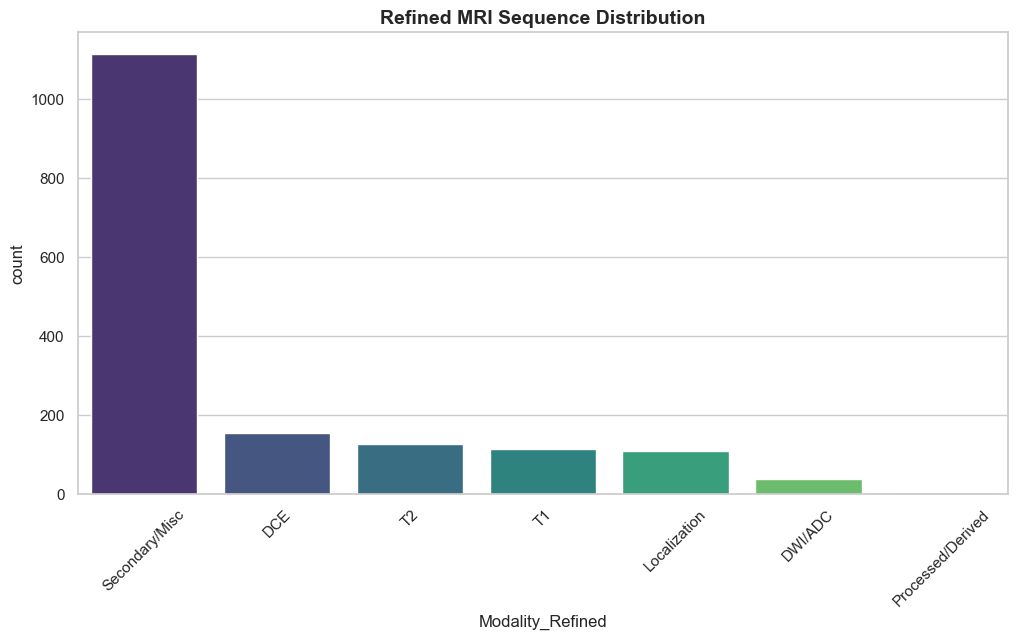

In [31]:
# Re-plot
plt.figure(figsize=(12,6))
sns.countplot(data=mri_df, x='Modality_Refined', palette='viridis', 
              order=mri_df['Modality_Refined'].value_counts().index)
plt.title("Refined MRI Sequence Distribution", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

In [ ]:
import os
import re
import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def explore_patient_mri(patient_mri_path):
    """
    Explore all MRI sequences for a single patient.
    patient_mri_path: Path to the '_mri_processed' folder
    """
    # 1. Get all available sequence folders for this patient
    sequences = [d for d in os.listdir(patient_mri_path) if os.path.isdir(os.path.join(patient_mri_path, d))]
    sequences.sort() # Keeps them in folder order

    if not sequences:
        print("No MRI sequences found in this directory.")
        return

    # 2. Define the display function
    def display_sequence(folder_name):
        seq_path = os.path.join(patient_mri_path, folder_name)
        
        # Load and naturally sort images within the chosen folder
        images = [img for img in os.listdir(seq_path) if img.endswith(".jpg")]
        images.sort(key=lambda f: int(re.sub('\D', '', f)))
        
        total_slices = len(images)
        
        # Nested interaction for slices
        def show_slice(slice_idx):
            img_path = os.path.join(seq_path, images[slice_idx])
            frame = cv2.imread(img_path)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            plt.figure(figsize=(10, 10))
            plt.imshow(frame)
            plt.title(f"Sequence: {folder_name}\nSlice {slice_idx+1}/{total_slices} | File: {images[slice_idx]}", fontsize=12)
            plt.axis('off')
            plt.show()
            
        # Create the slice slider that updates based on the selected folder
        interact(show_slice, slice_idx=widgets.IntSlider(
            min=0, max=total_slices-1, step=1, value=0,
            description='Slice:', layout={'width': '500px'}
        ))

    # 3. Create the dropdown for sequence folders
    interact(display_sequence, folder_name=widgets.Dropdown(
        options=sequences,
        value=sequences[0],
        description='Sequence:',
        layout={'width': '500px'}
    ))

# --- Usage Example ---
# Provide the path to the patient's processed MRI directory
patient_folder = "D:\\TCGA-BRCA\\Uploading\\MRI_and_SVS_Patches\\TCGA-AO-A0J8\\TCGA-AO-A0J8_mri_processed"
explore_patient_mri(patient_folder)

interactive(children=(Dropdown(description='Sequence:', layout=Layout(width='500px'), options=('1.000000-Loc-8…

Animation 


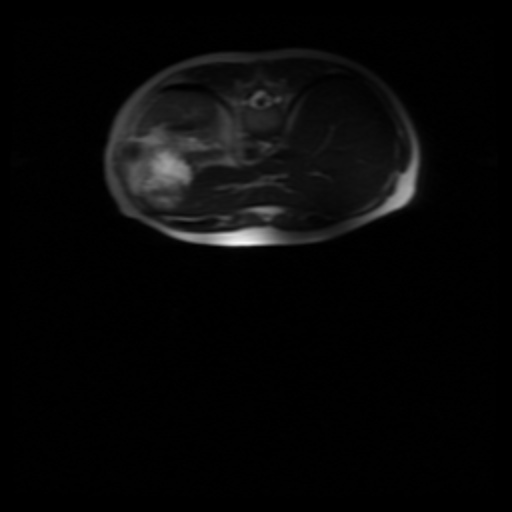
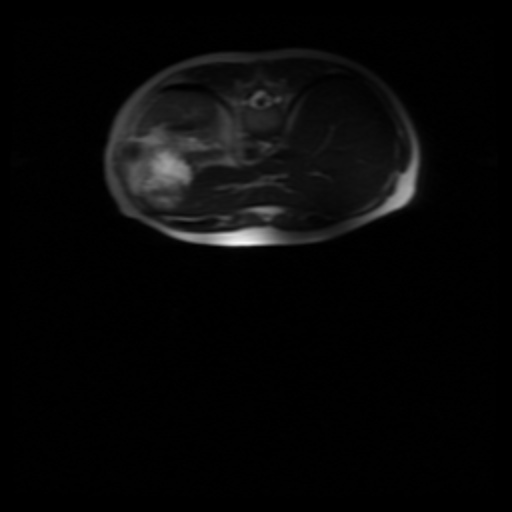
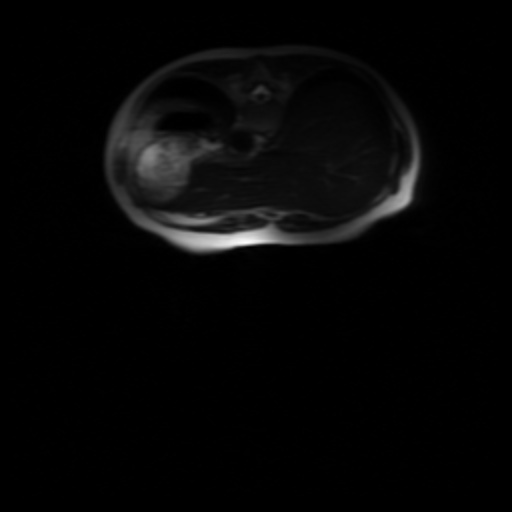
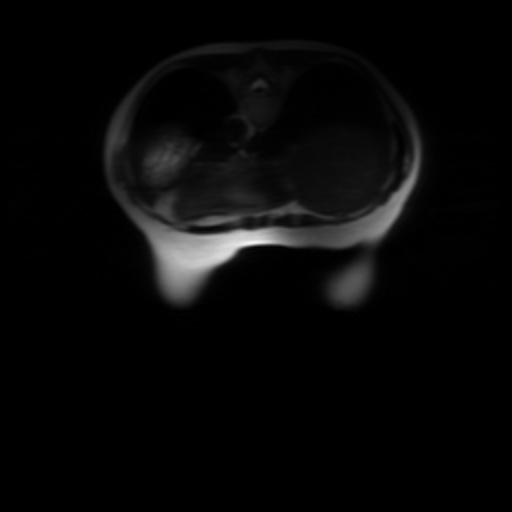
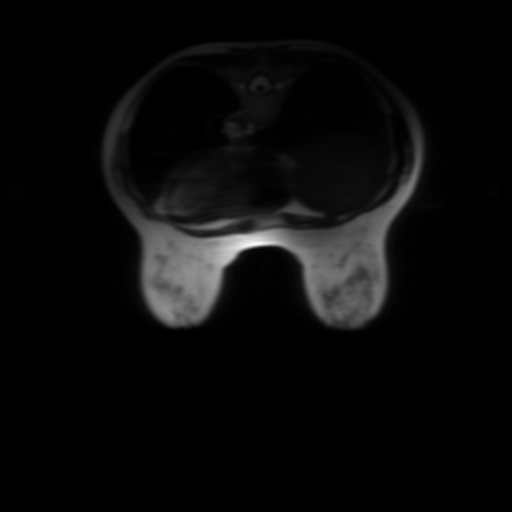
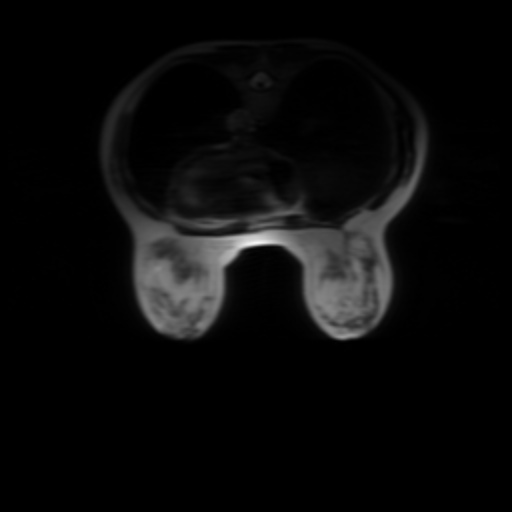
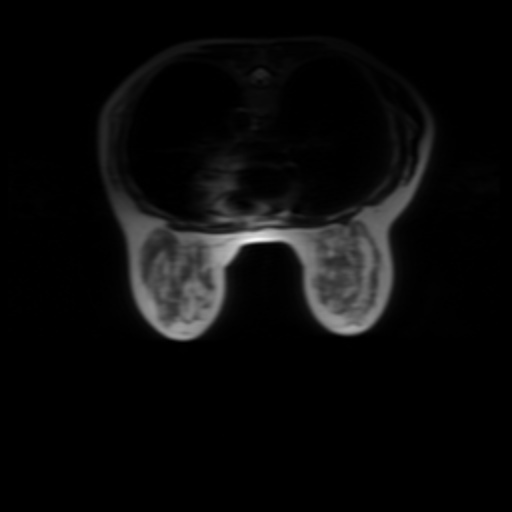
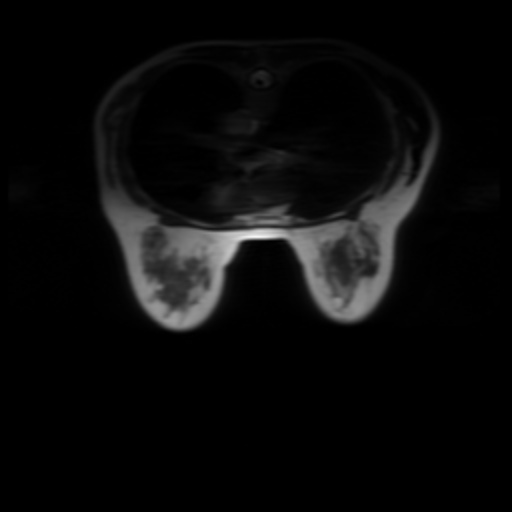
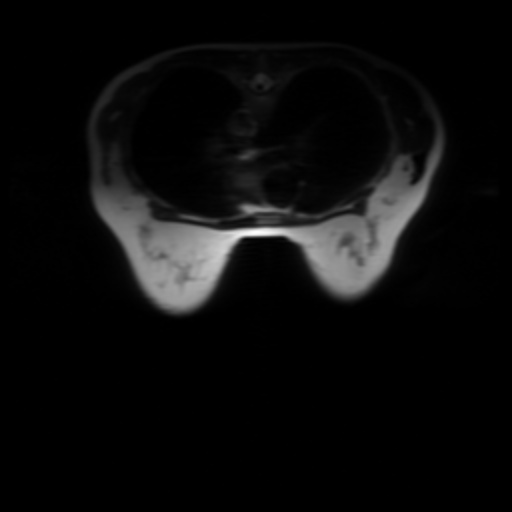
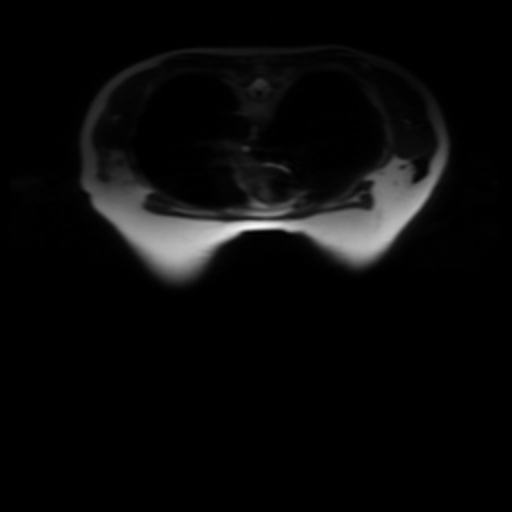
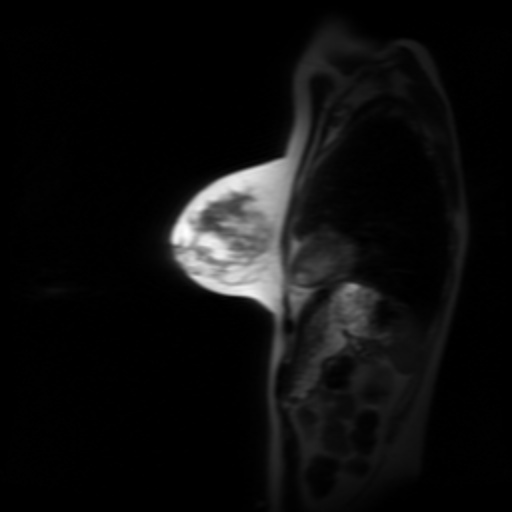
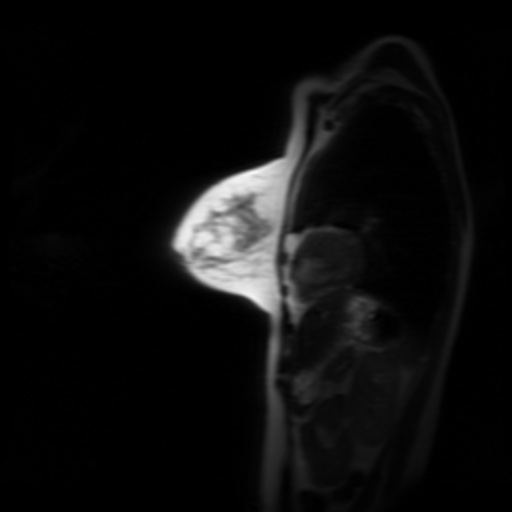
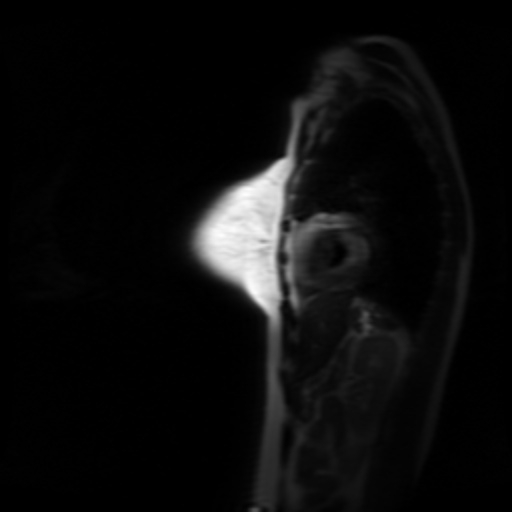
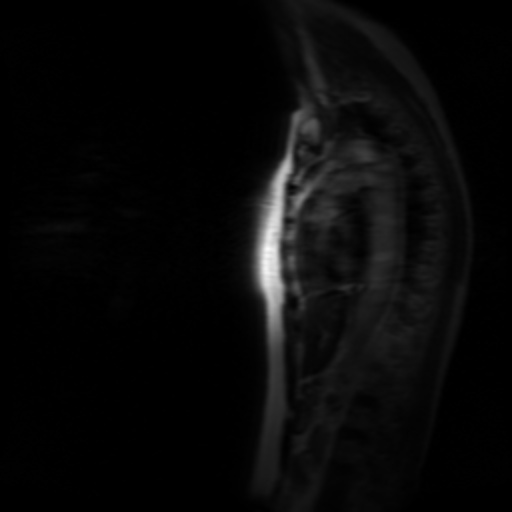
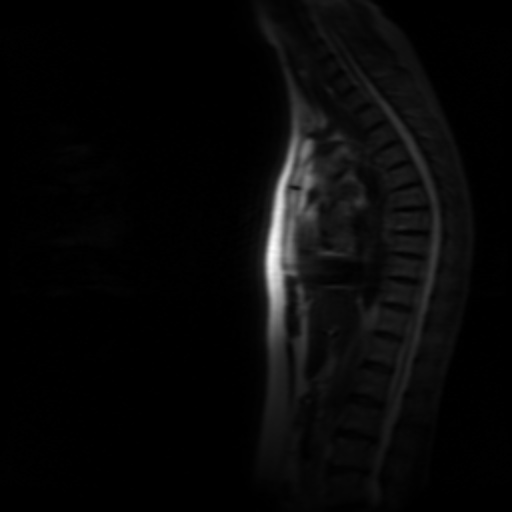
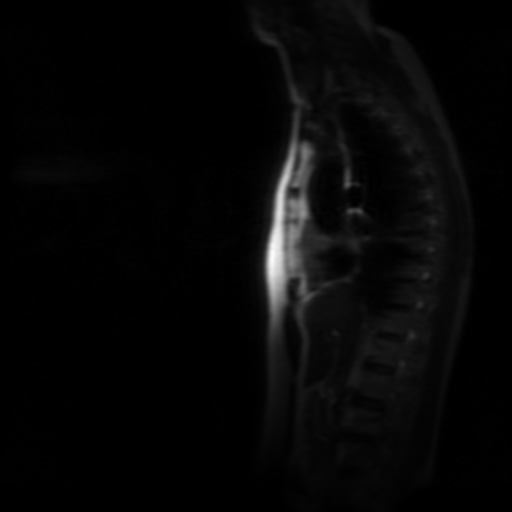
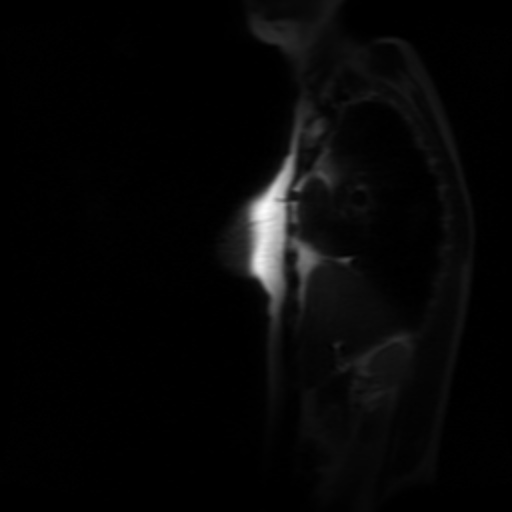
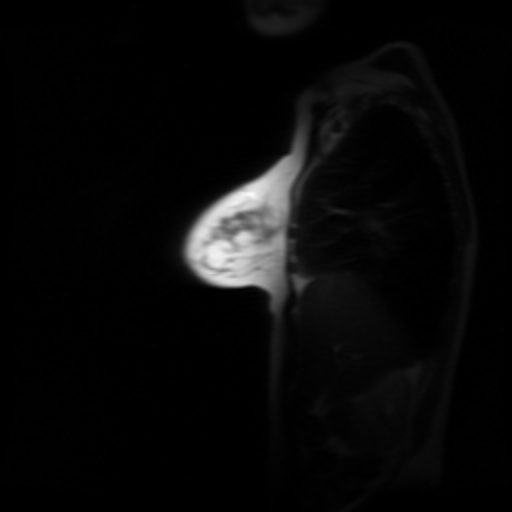
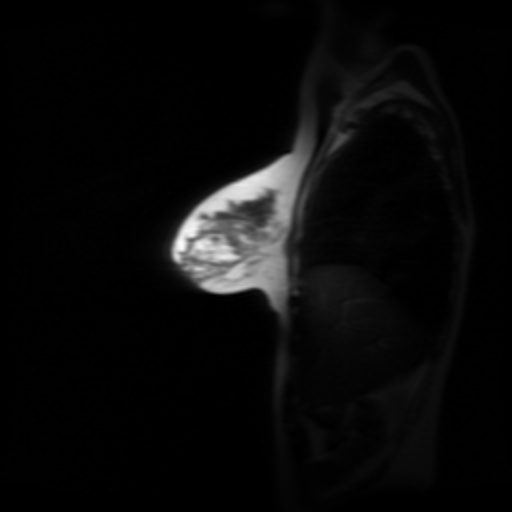
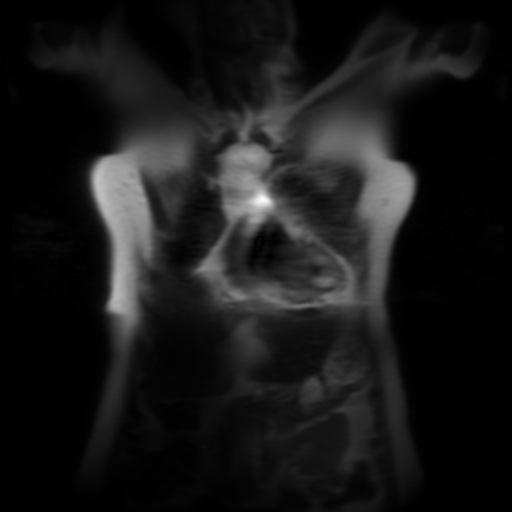
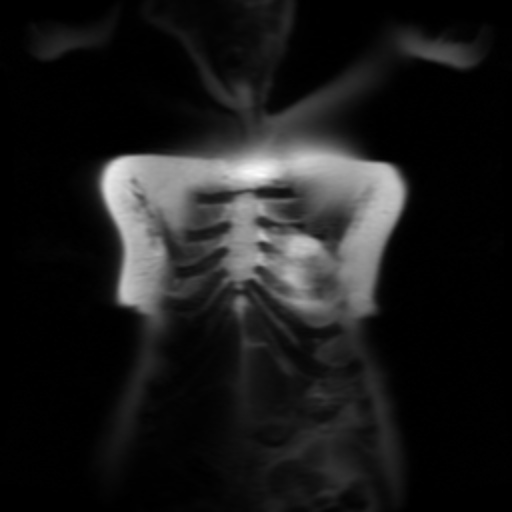
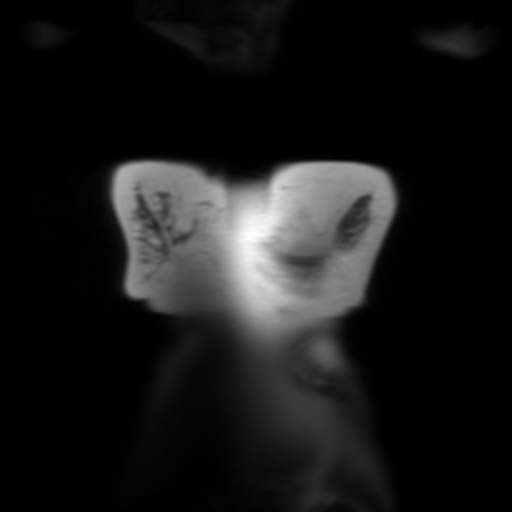
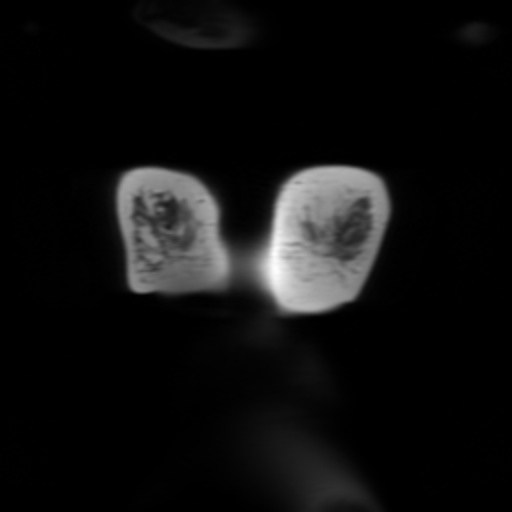
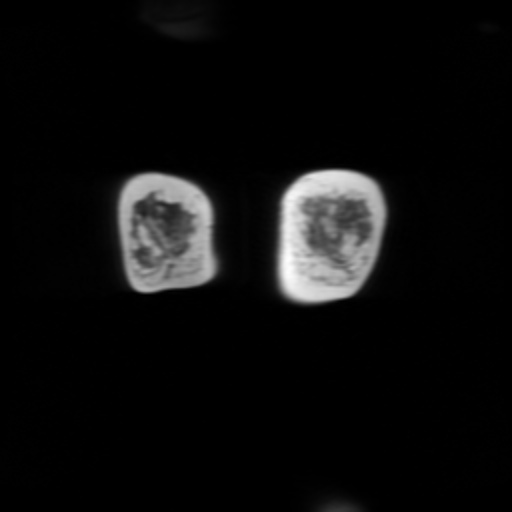
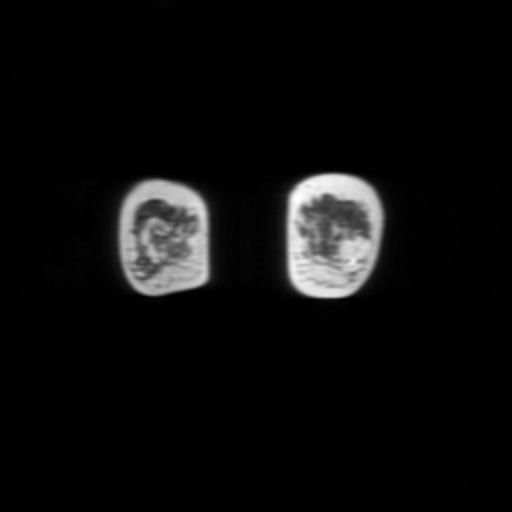
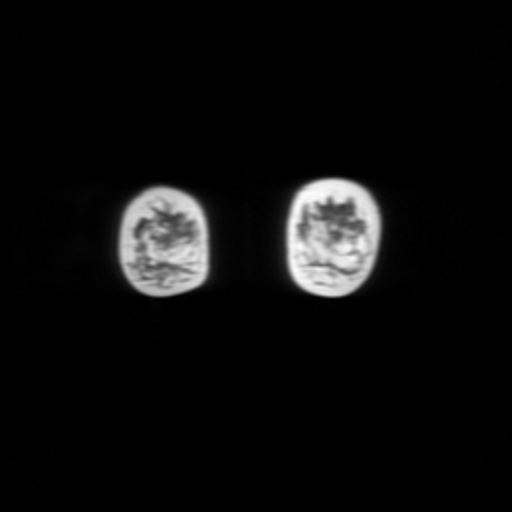
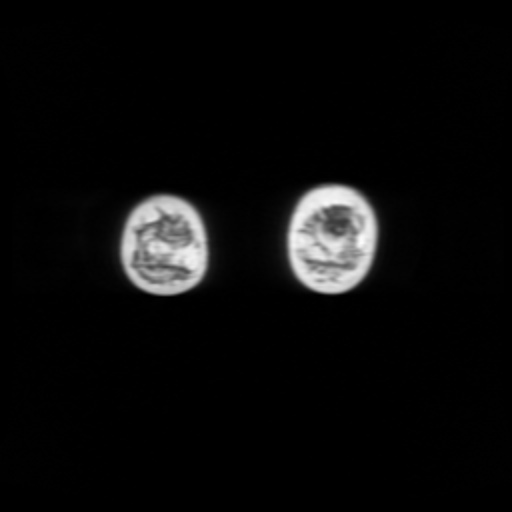
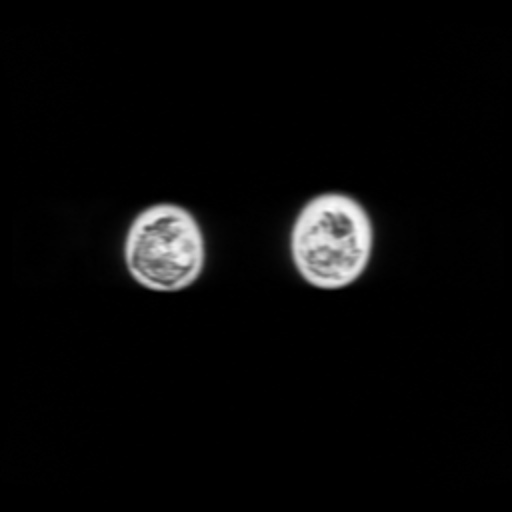

In [38]:
import os
import re
import base64
from IPython.display import HTML

def play_mri_javascript_gif(sequence_path, fps=15):
    # 1. Load and Natural Sort
    images = [img for img in os.listdir(sequence_path) if img.endswith(".jpg")]
    images.sort(key=lambda f: int(re.sub('\D', '', f)))
    
    if not images:
        return "No images found."

    # 2. Base64 Encoding
    encoded_images = []
    for img_name in images:
        with open(os.path.join(sequence_path, img_name), "rb") as f:
            encoded_str = base64.b64encode(f.read()).decode('utf-8')
            encoded_images.append(f"data:image/jpeg;base64,{encoded_str}")

    # 3. HTML/JS with Toggle Control
    interval = int(1000 / fps)
    unique_id = f"mri_gif_{hash(sequence_path) % 10**6}"
    
    html_code = f"""
    <div style="text-align: center; font-family: sans-serif;">
        <div style="margin-bottom: 10px;">
            <button onclick="toggle_{unique_id}()" id="btn_{unique_id}" 
                    style="padding: 5px 15px; border-radius: 5px; cursor: pointer; background: #444; color: white; border: none;">
                Stop Animation
            </button>
        </div>
        
        <img id="{unique_id}" 
             onclick="toggle_{unique_id}()"
             style="height: 400px; width: 400px; border: 2px solid #444; cursor: pointer; transition: opacity 0.2s;" 
             src="{encoded_images[0]}" 
             title="Click to Play/Pause" />
             
        <p style="color: #666; font-size: 12px; margin-top: 5px;">
            <b>Modality:</b> {os.path.basename(sequence_path)} <br>
            <i>(Click image to Play/Pause)</i>
        </p>
    </div>
    
    <script>
        (function() {{
            var images = {encoded_images};
            var i = 0;
            var isRunning = true;
            var imgElement = document.getElementById('{unique_id}');
            var btnElement = document.getElementById('btn_{unique_id}');
            var intervalId;

            function nextFrame() {{
                i = (i + 1) % images.length;
                imgElement.src = images[i];
            }}

            // Start the interval
            intervalId = setInterval(nextFrame, {interval});

            // Toggle function
            window.toggle_{unique_id} = function() {{
                if (isRunning) {{
                    clearInterval(intervalId);
                    btnElement.innerHTML = "Start Animation";
                    btnElement.style.background = "#28a745"; // Green for play
                    imgElement.style.opacity = "0.8";
                }} else {{
                    intervalId = setInterval(nextFrame, {interval});
                    btnElement.innerHTML = "Stop Animation";
                    btnElement.style.background = "#444"; // Dark for stop
                    imgElement.style.opacity = "1.0";
                }}
                isRunning = !isRunning;
            }};
        }})();
    </script>
    """
    
    return HTML(html_code)

# Usage
path = "D:\\TCGA-BRCA\\Uploading\\MRI_and_SVS_Patches\\TCGA-AO-A0J8\\TCGA-AO-A0J8_mri_processed\\1.000000-Loc-83949"
play_mri_javascript_gif(path, fps=12)

Radiogenomic Bridge"—the point where you successfully link raw imaging pixels (Phenotype) to molecular data (

In [45]:
# Force column names to lowercase and strip whitespace
Clinical_Demographic.columns = Clinical_Demographic.columns.str.strip()
Clinical_Treatment.columns = Clinical_Treatment.columns.str.strip()

# Define colors for the terminal/notebook output
BOLD = '\033[1m'
BLUE = '\033[94m'
CYAN = '\033[96m'
END = '\033[0m'

# Check if the column exists under a different name
# If it's named 'patient_id' or 'BARCODE', rename it:
if 'bcr_patient_barcode' not in Clinical_Demographic.columns:
    # Find the column that looks like a barcode (usually the first column)
    id_col = Clinical_Demographic.columns[0] 
    Clinical_Demographic.rename(columns={id_col: 'bcr_patient_barcode'}, inplace=True)

if 'bcr_patient_barcode' not in Clinical_Treatment.columns:
    id_col = Clinical_Treatment.columns[0]
    Clinical_Treatment.rename(columns={id_col: 'bcr_patient_barcode'}, inplace=True)

# Now perform the merge
df = pd.merge(Clinical_Demographic, Clinical_Treatment, on='bcr_patient_barcode', how='inner')

print(f"Merge successful! New cohort size: {len(df)} patients.")

Merge successful! New cohort size: 122 patients.


In [40]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

def build_imaging_inventory(root_path, clinical_df):
    imaging_data = []
    
    # regex to extract modality from folder names like "4.000000-T2 right-43124"
    modality_pattern = re.compile(r'-(T1|T2|DWI|VIBRANT|Loc)', re.IGNORECASE)

    for patient_id in os.listdir(root_path):
        mri_path = os.path.join(root_path, patient_id, f"{patient_id}_mri_processed")
        if not os.path.exists(mri_path): continue
        
        for seq_folder in os.listdir(mri_path):
            seq_path = os.path.join(mri_path, seq_folder)
            if not os.path.isdir(seq_path): continue
            
            # Extract modality
            match = modality_pattern.search(seq_folder)
            modality = match.group(1).upper() if match else "Other"
            
            # Get first valid image for gallery
            images = sorted([f for f in os.listdir(seq_path) if f.endswith('.jpg')])
            if not images: continue
            
            mid_slice = images[len(images)//2] # Grab the middle slice for representative view
            
            imaging_data.append({
                'Patient_ID': patient_id,
                'Modality': modality,
                'Sequence_Name': seq_folder,
                'Slice_Count': len(images),
                'Sample_Path': os.path.join(seq_path, mid_slice)
            })

    img_inventory = pd.DataFrame(imaging_data)
    # Merge with clinical data to get Subtypes
    rich_df = pd.merge(img_inventory, clinical_df[['bcr_patient_barcode', 'Subtype']], 
                       left_on='Patient_ID', right_on='bcr_patient_barcode')
    return rich_df

# Run the inventory
rich_mri_df = build_imaging_inventory("D:\\TCGA-BRCA\\Uploading\\MRI_and_SVS_Patches", df)

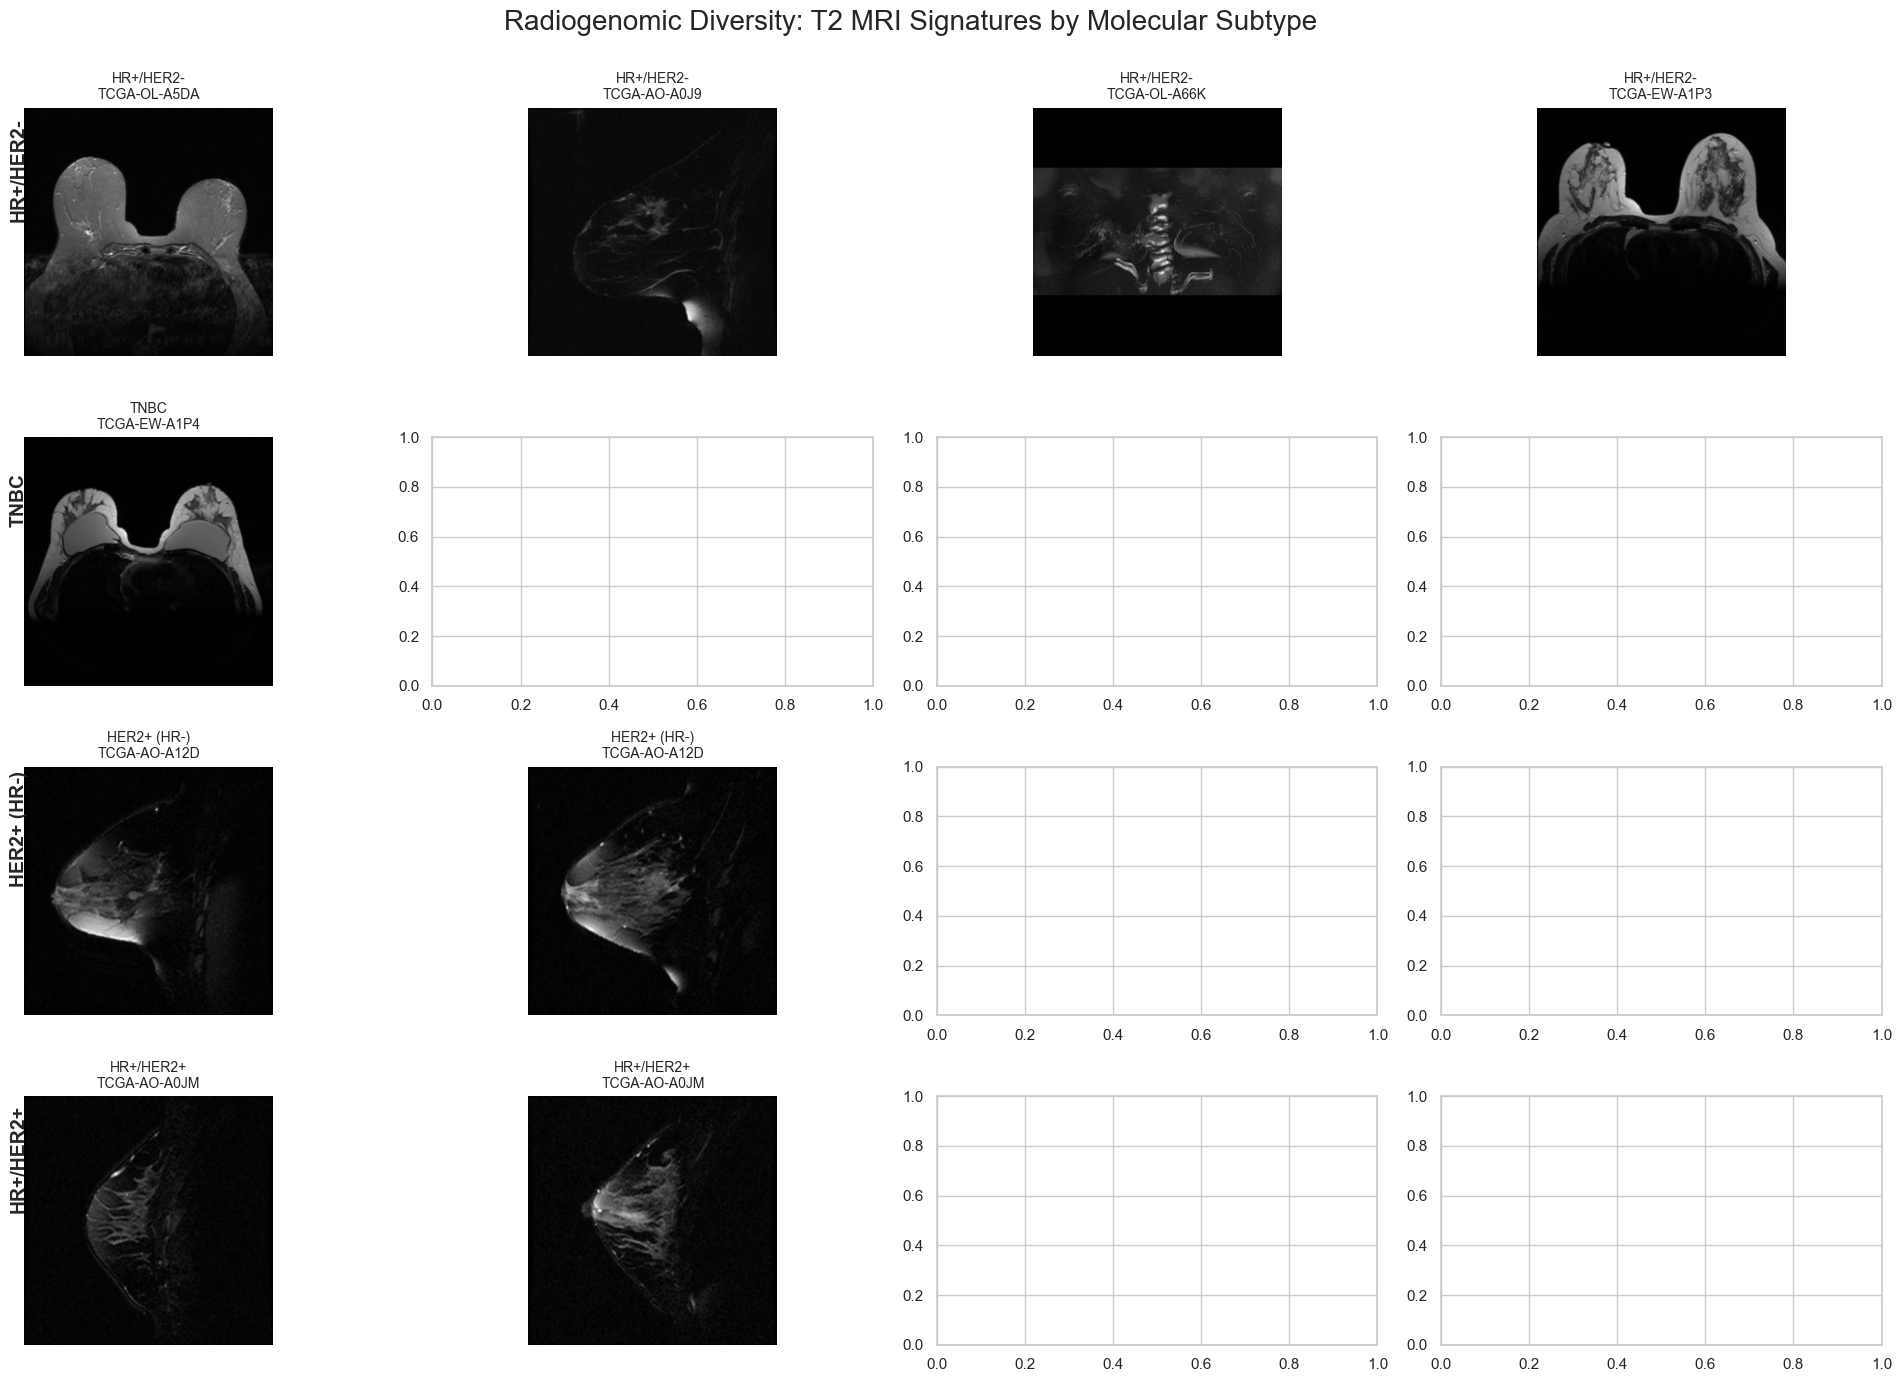

Radiogenomic Integration Summary
This visualization represents the integration of three distinct data domains: Molecular Subtyping, Clinical Metadata, and Multi-parametric MRI (mpMRI).
Each row represents a specific biological subtype of breast cancer, while each column provides a representative T2-weighted MRI slice from that cohort.

Data Availability Note:
The empty spaces visually demonstrate the sparsity of the TCGA dataset, where certain patients have clinical records but lacked a processed T2 MRI sequence at the time of the audit.
This provides a transparent look at the actual sample size available for each specific cancer subtype.


In [46]:
def show_radiogenomic_gallery(df, modality='T2', n_samples=4):
    subtypes = ['HR+/HER2-', 'TNBC', 'HER2+ (HR-)', 'HR+/HER2+']
    fig, axes = plt.subplots(len(subtypes), n_samples, figsize=(20, 15))
    
    for i, subtype in enumerate(subtypes):
        subset = df[(df['Subtype'] == subtype) & (df['Modality'] == modality)]
        
        if len(subset) == 0: continue
        
        samples = subset.sample(min(n_samples, len(subset)))
        
        for j, (_, row) in enumerate(samples.iterrows()):
            img = Image.open(row['Sample_Path'])
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].set_title(f"{subtype}\n{row['Patient_ID']}", fontsize=10)
            axes[i, j].axis('off')
            
        # Add Y-axis label for the subtype
        axes[i, 0].text(-30, 128, subtype, rotation=90, va='center', fontweight='bold', fontsize=14)

    plt.suptitle(f"Radiogenomic Diversity: {modality} MRI Signatures by Molecular Subtype", fontsize=20, y=0.95)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

show_radiogenomic_gallery(rich_mri_df, modality='T2')

# --- Summary Print ---

print(f"{BOLD}{BLUE}Radiogenomic Integration Summary{END}")
print(f"{CYAN}This visualization represents the integration of three distinct data domains: "
      f"Molecular Subtyping, Clinical Metadata, and Multi-parametric MRI (mpMRI).\n"
      f"Each row represents a specific biological subtype of breast cancer, while each column "
      f"provides a representative T2-weighted MRI slice from that cohort.\n\n"
      f"{BOLD}Data Availability Note:{END}{CYAN}\n"
      f"The empty spaces visually demonstrate the sparsity of the TCGA dataset, where certain "
      f"patients have clinical records but lacked a processed T2 MRI sequence at the time of "
      f"the audit.\n"
      f"This provides a transparent look at the actual sample size available for each specific "
      f"cancer subtype.{END}")

C:\Users\USER\AppData\Local\Temp\ipykernel_20024\2248932943.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=diagnostic_df, x='Modality', palette='rocket',
C:\Users\USER\AppData\Local\Temp\ipykernel_20024\2248932943.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diagnostic_df, x='Subtype', y='Slice_Count', palette='viridis')


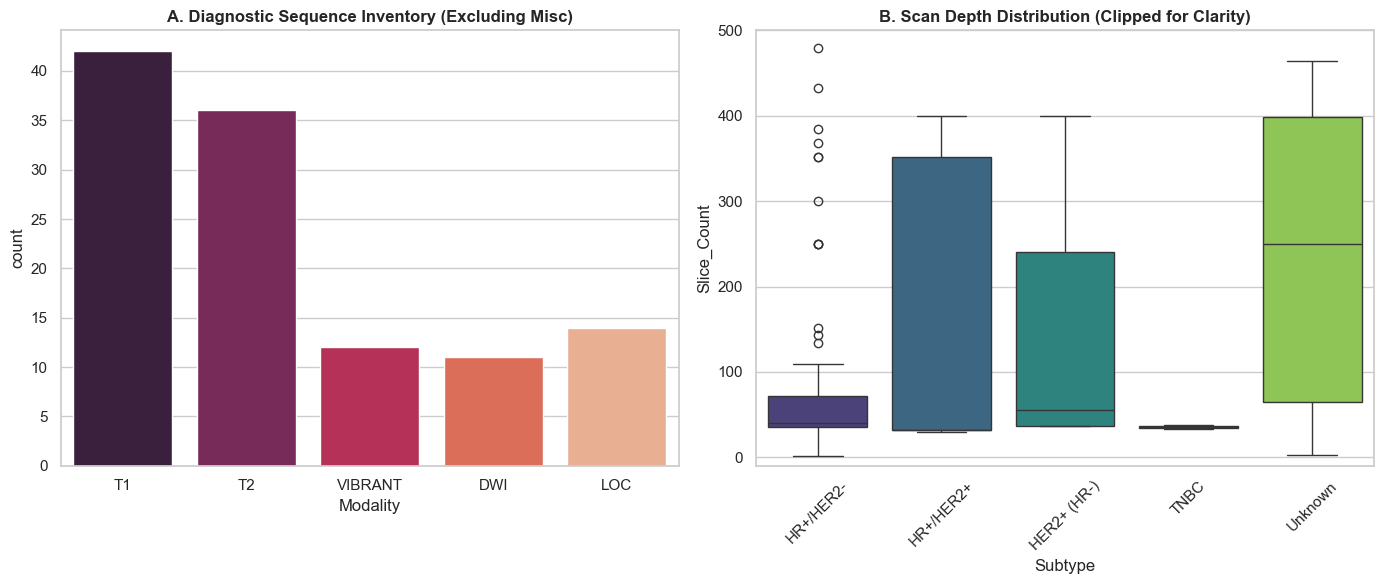

In [48]:
# Create a filtered version for a better research view
diagnostic_df = rich_mri_df[rich_mri_df['Modality'] != 'Other']

plt.figure(figsize=(14, 6))

# 1. Focused Modality Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=diagnostic_df, x='Modality', palette='rocket', 
              order=['T1', 'T2', 'VIBRANT', 'DWI', 'LOC'])
plt.title("A. Diagnostic Sequence Inventory (Excluding Misc)", fontweight='bold')

# 2. Slice Count with Outlier Clipping
plt.subplot(1, 2, 2)
# Clipping y-axis to 500 to see the boxes more clearly
sns.boxplot(data=diagnostic_df, x='Subtype', y='Slice_Count', palette='viridis')
plt.ylim(-10, 500) 
plt.xticks(rotation=45)
plt.title("B. Scan Depth Distribution (Clipped for Clarity)", fontweight='bold')

plt.tight_layout()
plt.show()